# Установки

In [ ]:
pip install unstructured\[pdf\]

In [ ]:
pip install pdfplumber transformers torch pillow

In [ ]:
pip install openai

In [ ]:
pip install -q qdrant-client

In [ ]:
pip install chonkie

In [ ]:
pip install "chonkie[semantic]"

In [ ]:
pip install pandas

In [ ]:
pip install scikit-learn

In [ ]:
pip install sentence_transformers

# Предподготовка

Для экспериментов были выбраны несколько игр и их дополнения

In [1]:
games_files = {
    "Дорога приключений": [
        "adventure road.pdf"
    ],
    "Бункер": [
        "bunker.pdf"
    ],
    "Каркассон": [
        "carcassonne.pdf"
    ],
    "Карточные войны": [
        "card wars.pdf"
    ],
    "Трамвай смерти": [
        "death tram.pdf"
    ],
    "Дюна: Империя": [
        "dune imperium_1.pdf",
        "dune imperium_2.pdf",
        "dune imperium_3.pdf",
        "dune imperium_4.pdf"
    ],
    "Взрывные котята": [
        "exploding kittens.pdf"
    ],
    "Игра престолов": [
        "got_1.pdf",
        "got_2.pdf",
        "motherofdragons.pdf"
    ],
    "Монополия Рик и Морти": [
        "monopoly.pdf"
    ],
    "Эверделл": [
        "jeverdell.pdf"
    ],
    "Битва за Рокуган": [
        "rokugan_1.pdf",
        "rokugan_2.pdf"
    ],
    "Манчкин": [
        "munchkin.pdf"
    ]
}

games = ["Дорога приключений", "Бункер", "Каркассон", "Карточные войны",
         "Трамвай смерти", "Дюна: Империя", "Взрывные котята", "Игра престолов", "Монополия Рик и Морти",
         "Манчкин", "Битва за Рокуган", "Эверделл"]

Используем unstructured для очистки и парсинга. Данная библиотека сама определяет тип текста (заголовок или просто текст), но делает это не всегда верно, поэтому будем делать это самостоятельно эвристически.

In [2]:
from unstructured.partition.pdf import partition_pdf

/Users/kapitolinakondakova/miniconda3/envs/rag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Смотрим какие есть метаданные у данных фрагментов

In [3]:
from unstructured.partition.pdf import partition_pdf

path = "files/got_1.pdf"

elements = partition_pdf(
    filename=path
)

elements[0].to_dict()

{'type': 'NarrativeText',
 'element_id': 'db33cc5c2939e2520691bab95126b698',
 'text': '«Железный трон мой по праву. Всякий, кто это отрицает, — мой враг». — Станнис Баратеон.',
 'metadata': {'coordinates': {'points': ((74.8069, 224.03300000000002),
    (74.8069, 242.04899999999998),
    (304.39329999999984, 242.04899999999998),
    (304.39329999999984, 224.03300000000002)),
   'system': 'PixelSpace',
   'layout_width': 609.449,
   'layout_height': 790.866},
  'file_directory': 'files',
  'filename': 'got_1.pdf',
  'last_modified': '2026-02-02T21:43:18',
  'page_number': 2,
  'languages': ['rus'],
  'filetype': 'application/pdf'}}

In [4]:
elements[0].__class__.__name__

'NarrativeText'

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("API_KEY")

### Функция для запросов к модели

In [6]:
from openai import OpenAI

client = OpenAI(
    base_url="https://api.polza.ai/api/v1",
    api_key=API_KEY,
)

def query(content, model="qwen/qwen3-next-80b-a3b-instruct") -> str:
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": content,
            }
        ],
    )

    return completion.choices[0].message.content

### Подключаем Qdrant

In [7]:
from qdrant_client import QdrantClient

qclient = QdrantClient(
    url="http://localhost:6333"
)

qclient.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='games_chunks_text_embedding_3_small'), CollectionDescription(name='games_chunks_e5_small'), CollectionDescription(name='games_chunks_text_embedding_3_large'), CollectionDescription(name='games_chunks_e5_base'), CollectionDescription(name='games_chunks_qwen3_embedding_8b'), CollectionDescription(name='games_chunks_bge_m3'), CollectionDescription(name='games_chunks_gemini_embedding_001')])

In [8]:
# collections = qclient.get_collections().collections

# for col in collections:
#     qclient.delete_collection(col.name)
#     print(f"Deleted: {col.name}")

# Подготовка данных, эксперименты с индексированием

Основная проблема pdf-файлов (в частности правил настольных игр), что у них нет одинаковой структуры и зачастую при парсинге даже та структура с разделами которая была может "съехать".

Так же при парсинге элементы могут идти не в правильном порядке: например, в документах с несколькими колонками unstructured и другие PDF-парсеры не всегда восстанавливают естественный порядок чтения. Поэтому перед чанкингом мы сначала переупорядочиваем страницу на уровне layout. Для этого строим двумерную карту плотности текста по bbox-координатам элементов, бинаризуем её и объединяем соседние заполненные области в связные компоненты; каждая такая компонента рассматривается как отдельный блок. Для сглаживания мелких разрывов между близко расположенными фрагментами дополнительно применяем дилатацию, а затем нумеруем полученные блоки в порядке чтения — по колонкам слева направо и внутри каждой колонки сверху вниз.

Для чанкирования мы попробуем несколько методов на бейзлайн модели, далее позже выберем несколько моделей эмбеддингов и посмотрим, что будет давать наилучший результат. 

Проводить тесты мы будем на таблице вопросов-ответов по данным настольным играм, ответами будут фрагменты из правил, которые отвечают на данный вопрос. Посмотрим на разные метрики (Hit@K и MRR). Так как при разных методах чанкирования фрагмент с ответом может иметь разные границы и формулировки, для оценки релевантности используется оценка того, насколько чанк покрыл правильный ответ.

Проверяемые методы:

1) Фиксированное разбиение
2) Разбиение по предложениям
3) Семантическое разбиение
4) Разбиение по заголовкам
5) Рекурсивное разбиение по кластерам

Первые 3 метода реализуем с помощью библиотеки Chonkie

4 способ будет реализован с помощью LLM и эмпирических правил. На первом этапе с помощью библиотеки unstructured выделяются строки, потенциально являющиеся заголовками. Поскольку данный инструмент может ошибочно классифицировать короткие строки как заголовки, на втором этапе эти кандидаты дополнительно проверяются языковой моделью, которая определяет, является ли строка логическим заголовком раздела. В случае положительного решения формируется новый чанк, включающий текст до следующего подтверждённого заголовка при условии соблюдения ограничений по длине.

В 5 способе мы будем использовать наше разбиение по блокам. Рекурсивно делим сначала по страницам, потом по блокам, потом по предложениям

Пока что на данном этапе ограничимся только названием игры в метаданных.

### Сортировка и кластеризация

In [8]:
class Element:
    def __init__(self, el):
        self.text = el.text
        self.x0 = el.metadata.coordinates.points[0][0]
        self.x1 = el.metadata.coordinates.points[2][0]
        self.y0 = el.metadata.coordinates.points[0][1]
        self.y1 = el.metadata.coordinates.points[2][1]
        self.page = el.metadata.page_number
        self.type = el.__class__.__name__
        self.cluster = 0
        
    def __str__(self):
        data = {
            "type": self.type,
            "page": self.page,
            "x0": round(self.x0, 2),
            "y0": round(self.y0, 2),
            "text": self.text,
            "cluster": self.cluster
        }

        return "\n".join(f"{k}: {v}" for k, v in data.items())

In [9]:
from collections import defaultdict
games_texts_splitted = defaultdict(list)

for game_name in games:
    for file in games_files[game_name]:
        path = f'files/{file}'
        elements = partition_pdf(path)
        text_splitted = [Element(el) for el in elements if el.text]
        games_texts_splitted[game_name].append(text_splitted)

Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]
Cannot set non-stroke color because expected 4 components but got [1]


Cannot set non-stroke color because expected 4 components but got [1]


Давайте посмотрим как выглядит наша сегментация

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def plot_heatmap(elements, page_num=1, x_bins=100, y_bins=100, save_path="heatmap.png"):
    elems = [e for e in elements if e.page == page_num]

    if not elems:
        print("No elements on this page")
        return

    x0s = np.array([e.x0 for e in elems])
    x1s = np.array([e.x1 for e in elems])
    y0s = np.array([e.y0 for e in elems])
    y1s = np.array([e.y1 for e in elems])

    min_x, max_x = x0s.min(), x1s.max()
    min_y, max_y = y0s.min(), y1s.max()

    x_edges = np.linspace(min_x, max_x, x_bins + 1)
    y_edges = np.linspace(min_y, max_y, y_bins + 1)

    heatmap = np.zeros((y_bins, x_bins))

    x_left = x_edges[:-1]
    x_right = x_edges[1:]
    y_top = y_edges[:-1]
    y_bottom = y_edges[1:]

    for i in range(len(elems)):
        overlaps_x = (x1s[i] > x_left) & (x0s[i] < x_right)
        overlaps_y = (y1s[i] > y_top) & (y0s[i] < y_bottom)

        heatmap += np.outer(overlaps_y, overlaps_x)

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    plt.figure()
    plt.imshow(heatmap, origin='upper')
    plt.title(f"Heatmap")
    plt.colorbar()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

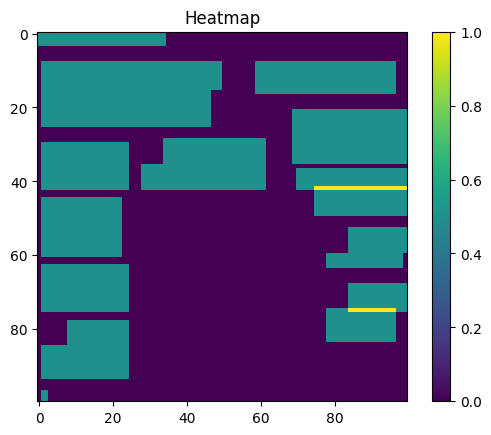

In [11]:
plot_heatmap(games_texts_splitted["Дюна: Империя"][0], page_num=2)

In [12]:
from collections import defaultdict
import numpy as np
from scipy.ndimage import label, binary_dilation


def split_blocks_2d_heatmap(elements, x_bins=100, y_bins=100, threshold=0.05):
    by_page = defaultdict(list)
    for e in elements:
        by_page[e.page].append(e)

    for page, elems in by_page.items():
        if len(elems) < 5:
            for e in elems:
                e.cluster = 0
            continue

        x0s = np.array([e.x0 for e in elems], dtype=float)
        x1s = np.array([e.x1 for e in elems], dtype=float)
        y0s = np.array([e.y0 for e in elems], dtype=float)
        y1s = np.array([e.y1 for e in elems], dtype=float)

        min_x, max_x = x0s.min(), x1s.max()
        min_y, max_y = y0s.min(), y1s.max()

        x_edges = np.linspace(min_x, max_x, x_bins + 1)
        y_edges = np.linspace(min_y, max_y, y_bins + 1)

        heatmap = np.zeros((y_bins, x_bins), dtype=float)

        x_left = x_edges[:-1]
        x_right = x_edges[1:]
        y_top = y_edges[:-1]
        y_bottom = y_edges[1:]

        # ---- heatmap ----
        for i in range(len(elems)):
            overlaps_x = (x1s[i] > x_left) & (x0s[i] < x_right)
            overlaps_y = (y1s[i] > y_top) & (y0s[i] < y_bottom)
            heatmap += np.outer(overlaps_y, overlaps_x)

        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        # ---- mask ----
        mask = heatmap >= threshold
        mask = binary_dilation(mask, structure=np.ones((3, 3)))

        labeled, num = label(mask, structure=np.ones((3, 3), dtype=int))

        if num == 0:
            for e in elems:
                e.cluster = 0
            continue

        # ---- центры блоков ----
        cluster_coords = {}
        for c in range(1, num + 1):
            ys, xs = np.where(labeled == c)
            if len(xs) == 0:
                continue
            cx = xs.mean()
            cy = ys.mean()
            cluster_coords[c] = (cx, cy)

        # ---- определяем колонки ----
        xs_centers = np.array([v[0] for v in cluster_coords.values()])

        sorted_x = np.sort(xs_centers)
        gaps = np.diff(sorted_x)

        if len(gaps) == 0:
            splits = []
        else:
            gap_threshold = np.mean(gaps) * 1.5
            splits = sorted_x[:-1][gaps > gap_threshold]

        # функция: в какую колонку попадает блок
        def get_column(cx):
            col = 0
            for s in splits:
                if cx > s:
                    col += 1
            return col

        # ---- группируем по колонкам ----
        columns = defaultdict(list)

        for c, (cx, cy) in cluster_coords.items():
            col = get_column(cx)
            columns[col].append((c, cx, cy))

        # ---- сортировка колонок слева направо ----
        ordered_cols = sorted(columns.items(), key=lambda x: np.mean([v[1] for v in x[1]]))

        ordered = []

        for _, col_items in ordered_cols:
            col_sorted = sorted(col_items, key=lambda x: x[2])
            ordered.extend(col_sorted)

        remap = {c: i + 1 for i, (c, _, _) in enumerate(ordered)}

        # ---- применяем ----
        new_labeled = np.zeros_like(labeled)

        for old, new in remap.items():
            new_labeled[labeled == old] = new
        
        labeled = new_labeled

        # ---- назначаем элементам ----
        for i, e in enumerate(elems):
            x_mask = (x1s[i] > x_left) & (x0s[i] < x_right)
            y_mask = (y1s[i] > y_top) & (y0s[i] < y_bottom)

            region = labeled[np.ix_(y_mask, x_mask)]

            if region.size == 0:
                e.cluster = 0
                continue

            vals, counts = np.unique(region, return_counts=True)

            nonzero = vals != 0
            vals = vals[nonzero]
            counts = counts[nonzero]

            e.cluster = int(vals[np.argmax(counts)]) if len(vals) else 0

    return elements

In [13]:
from tqdm import tqdm

for game_name in tqdm(games, desc="Processing games"):
    for ind in range(len(games_texts_splitted[game_name])):
        
        split_blocks_2d_heatmap(games_texts_splitted[game_name][ind])
        
        games_texts_splitted[game_name][ind] = sorted(
            games_texts_splitted[game_name][ind],
            key=lambda e: (e.page, e.cluster, e.y0, e.x0)
        )

Processing games: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 40.59it/s]


Очистим от номеров страниц повторяющихся строк и т.д.

In [14]:
allowed_types = {"NarrativeText", "ListItem", "Title", "Text"}

def is_page_number(e):
    t = (e.text or "").strip()
    if t.isdigit():
        return True
    return False

def clean_elements(elements):
    allowed_types = {"NarrativeText", "ListItem", "Title", "Text"}

    seen = set()
    cleaned = []

    for e in elements:
        # 1. тип
        if e.type not in allowed_types:
            continue

        # 2. пустой текст
        if not e.text or not e.text.strip():
            continue

        # 3. номер страницы
        if is_page_number(e):
            continue

        # 4. дубликаты текста
        if e.text in seen:
            continue
        seen.add(e.text)

        cleaned.append(e)

    return cleaned


In [15]:
for game_name in tqdm(games, desc="Processing games"):
    for ind in range(len(games_texts_splitted[game_name])):
        games_texts_splitted[game_name][ind] = clean_elements(games_texts_splitted[game_name][ind])

Processing games: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 4123.52it/s]


сэмпл

In [16]:
def print_elements(elements, n=5):
    for e in elements[:n]:
        print(e)
        print()

print_elements(games_texts_splitted["Дюна: Империя"][0], n=50)

type: NarrativeText
page: 1
x0: 46.77
y0: 153.07
text: На просторах Известной Вселенной нет более ценного ресурса, чем Пряность. Её добывают только на пустынной планете Арракис, более известной как Дюна. Великие Дома Империи соперничают за контроль над Пряностью, добиваясь поддержки влиятельных фракций. Законодатели Ландсраада. Корпорация КООАМ с её ненасытной жаждой прибыли. Провидческий орден Бене Гессерит. Гильдия Космогации, обладающая монополией на межзвёздные путешествия. Фримены — стойкие воины пустыни. Даже сам Император порой вступает в борьбу за влияние. Конфликт неизбежен, его исход непредсказуем, но всем ясно одно…
cluster: 0

type: Title
page: 1
x0: 46.77
y0: 317.03
text: Кто контролирует Пряность — контролирует Вселенную.
cluster: 0

type: NarrativeText
page: 2
x0: 31.19
y0: 79.39
text: «Дюна. Империя» — настольная игра с размещением рабочих и построением собственной колоды. Игра основана на культовой книжной серии «Дюна» Фрэнка Герберта, Брайана Герберта и Кевина Дж. Анд

Далее можно убедиться по картинке, что все работает очень даже хорошо

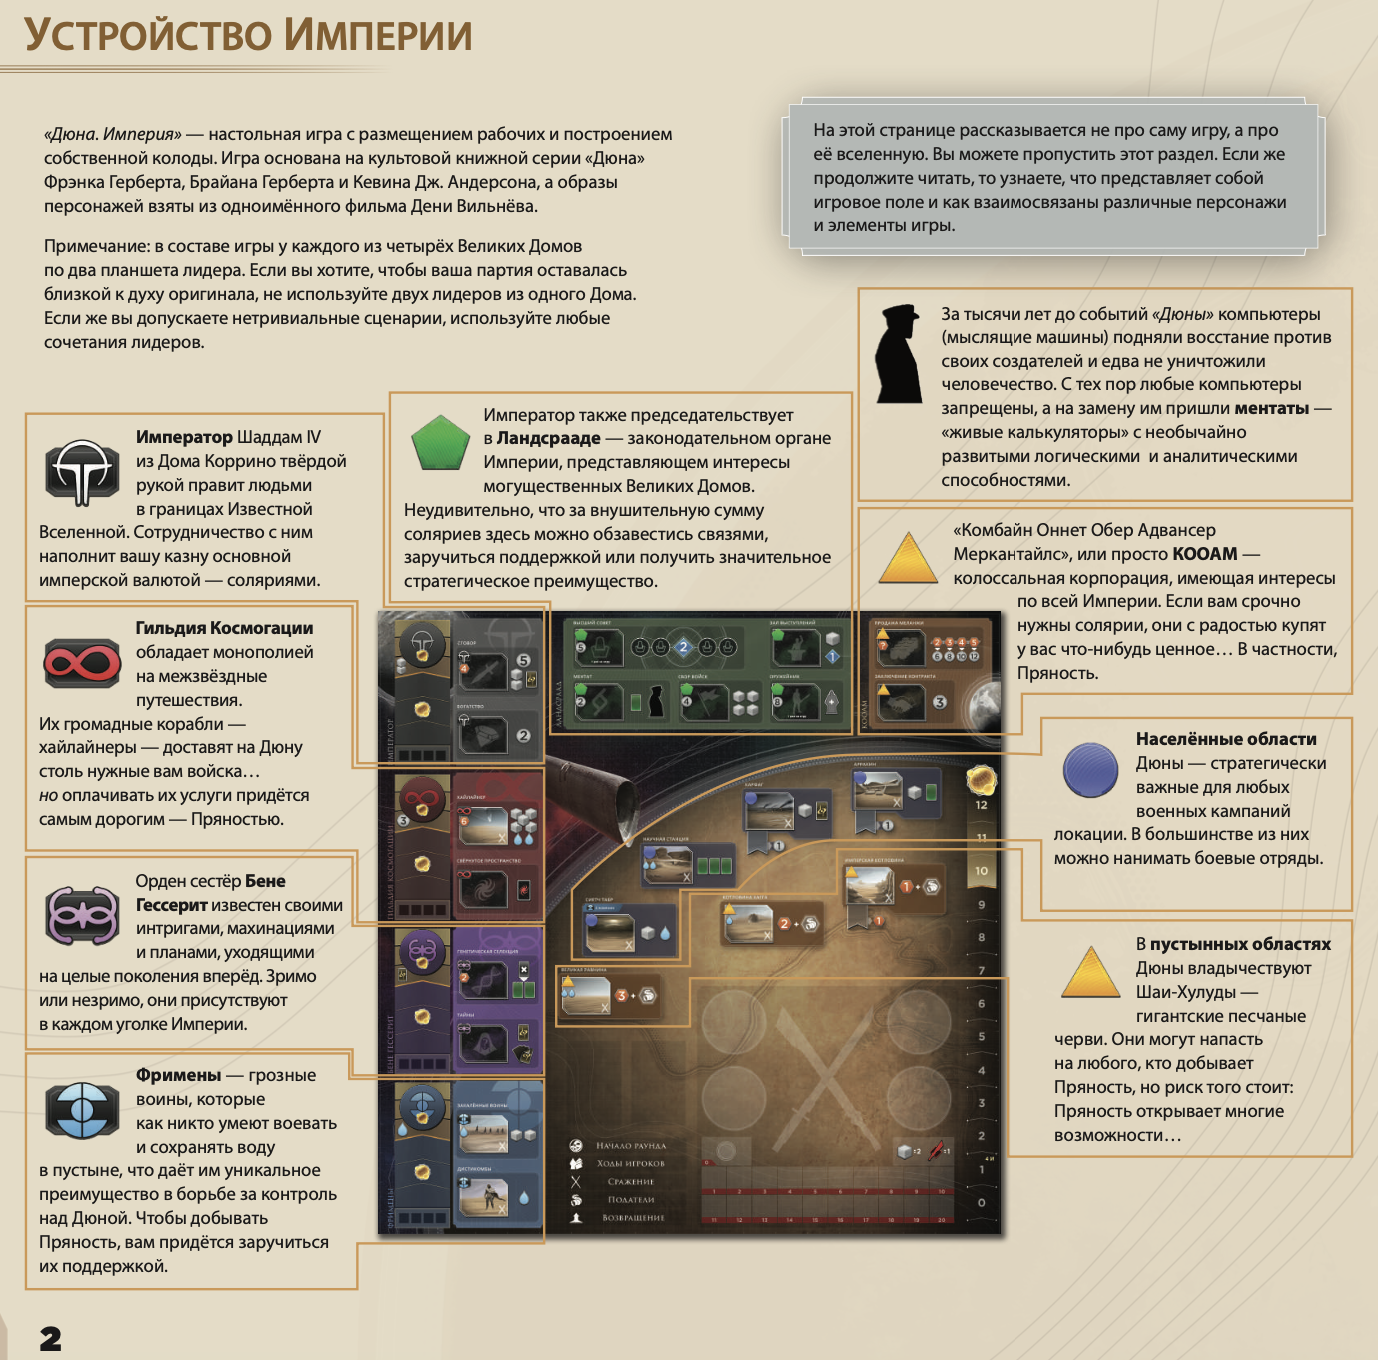

In [17]:
from IPython.display import Image, display

display(Image("page.png"))

In [18]:
games_texts = defaultdict(list)

for game_name in games:
    for elements in games_texts_splitted[game_name]:
        games_texts[game_name].append("\n".join([el.text for el in elements]))

### Фиксированное разбиение

In [19]:
from chonkie import TokenChunker

# --- настройки ---
CHUNK_SIZE = 512
OVERLAP = 64
SAMPLE_N = 5

def token_chunker(chunk_size, overlap=64):
    chunker = TokenChunker(
        chunk_size=chunk_size,
        chunk_overlap=overlap
    )
    
    games_chunks_token = {}
    
    for game_name in games_texts:
        games_chunks_token[game_name] = []
        for text in games_texts[game_name]:
            chunks = chunker.chunk(text)
            games_chunks_token[game_name].extend([ch.text for ch in chunks])
    return games_chunks_token

games_chunks_token = token_chunker(CHUNK_SIZE, OVERLAP)

# --- вывод сэмпла ---
sample_game = "Игра престолов"
sample_chunks = games_chunks_token[sample_game]

print(f"GAME: {sample_game}")
print(f"TOTAL CHUNKS: {len(sample_chunks)}")
print("-" * 80)

for i, ch in enumerate(sample_chunks[:SAMPLE_N], 1):
    preview = ch.replace("\n", " ")
    print(f"[Chunk {i}]")
    print(preview)
    print("-" * 80)


GAME: Игра престолов
TOTAL CHUNKS: 332
--------------------------------------------------------------------------------
[Chunk 1]
«Железный трон мой по праву. Всякий, кто это отрицает, — мой враг». — Станнис Баратеон. «Вся страна это отрицает, брат. Старики отрицают это предсмертными хрипами, нерождённые дети отрицают это в утробах матерей. Это отрицают в Дорне, это отрицают на Стене. Никто не хочет видеть тебя своим королём… Твоё право на трон может быть сколь угодно законным, но моё войско больше». — Ренли Баратеон. «В игре престолов вы или побеждаете, или умираете». — Серсея Ланнистер. ОБ ИГРЕ Настольная «Игра престолов», созданная
--------------------------------------------------------------------------------
[Chunk 2]
Серсея Ланнистер. ОБ ИГРЕ Настольная «Игра престолов», созданная на основе цикла романов Джорджа Мартина «Песнь льда и пламени», примет от трёх до шести игроков в мир эпических событий кровопролитной саги. Каждому из участников «Игры престолов» предстоит возглавить 

### Разбиение по предложениям

In [20]:
from chonkie import SentenceChunker

# --- настройки ---
CHUNK_SIZE = 512
OVERLAP = 64
SAMPLE_N = 5

def sentence_chunker(chunk_size, overlap=64):

    chunker = SentenceChunker(
        chunk_size=chunk_size,
        chunk_overlap=overlap
    )
    
    games_chunks_sentence = {}
    
    for game_name in games_texts:
        games_chunks_sentence[game_name] = []
        for text in games_texts[game_name]:
            chunks = chunker.chunk(text)
            games_chunks_sentence[game_name].extend([ch.text for ch in chunks])
    return games_chunks_sentence

games_chunks_sentence = sentence_chunker(CHUNK_SIZE, OVERLAP)

# --- вывод сэмпла ---
sample_game = "Игра престолов"
sample_chunks = games_chunks_sentence[sample_game]

print(f"GAME: {sample_game}")
print(f"TOTAL CHUNKS: {len(sample_chunks)}")
print("-" * 80)

for i, ch in enumerate(sample_chunks[:SAMPLE_N], 1):
    preview = ch.replace("\n", " ")
    print(f"[Chunk {i}]")
    print(preview)
    print("-" * 80)

GAME: Игра престолов
TOTAL CHUNKS: 338
--------------------------------------------------------------------------------
[Chunk 1]
«Железный трон мой по праву. Всякий, кто это отрицает, — мой враг». — Станнис Баратеон. «Вся страна это отрицает, брат. Старики отрицают это предсмертными хрипами, нерождённые дети отрицают это в утробах матерей. Это отрицают в Дорне, это отрицают на Стене. Никто не хочет видеть тебя своим королём… Твоё право на трон может быть сколь угодно законным, но моё войско больше». — Ренли Баратеон. «В игре престолов вы или побеждаете, или умираете». — Серсея Ланнистер. ОБ ИГРЕ 
--------------------------------------------------------------------------------
[Chunk 2]
— Серсея Ланнистер. ОБ ИГРЕ Настольная «Игра престолов», созданная на основе цикла романов Джорджа Мартина «Песнь льда и пламени», примет от трёх до шести игроков в мир эпических событий кровопролитной саги. Каждому из участников «Игры престолов» предстоит возглавить один из Великих домов, сражающихся з

### Семантическое разбиение

Семантическое разбиение реализовано с использованием дефолтной embedding-модели, работающей локально, без обращения к внешним API.

In [21]:
from chonkie import SemanticChunker
from tqdm import tqdm

# --- настройки ---
CHUNK_SIZE = 512
SAMPLE_N = 5

def semantic_chunker(chunk_size):
    EMB_MODEL = "minishlab/potion-base-32M"
    THRESHOLD = 0.75
    SIM_WINDOW = 3
    SKIP_WINDOW = 0
    
    chunker = SemanticChunker(
        embedding_model=EMB_MODEL,
        threshold=THRESHOLD,
        chunk_size=chunk_size,
        similarity_window=SIM_WINDOW,
        skip_window=SKIP_WINDOW,
        min_sentences_per_chunk=2
    )
    
    games_chunks_semantic = {}
    
    for game_name in tqdm(games_texts, desc="Chunking documents"):
        games_chunks_semantic[game_name] = []
        for text in games_texts[game_name]:
            chunks = chunker.chunk(text)
            games_chunks_semantic[game_name].extend([ch.text for ch in chunks])
    return games_chunks_semantic

games_chunks_semantic = semantic_chunker(CHUNK_SIZE)

# --- вывод сэмпла ---
sample_game = "Игра престолов"
sample_chunks = games_chunks_semantic[sample_game]

print(f"GAME: {sample_game}")
print(f"TOTAL CHUNKS: {len(sample_chunks)}")
print("-" * 80)

for i, ch in enumerate(sample_chunks[:SAMPLE_N], 1):
    preview = ch.replace("\n", " ")
    print(f"[Chunk {i}]")
    print(preview)
    print("-" * 80)

Chunking documents: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 14.57it/s]

GAME: Игра престолов
TOTAL CHUNKS: 523
--------------------------------------------------------------------------------
[Chunk 1]
«Железный трон мой по праву. Всякий, кто это отрицает, — мой враг». — Станнис Баратеон. 
--------------------------------------------------------------------------------
[Chunk 2]
«Вся страна это отрицает, брат. Старики отрицают это предсмертными хрипами, нерождённые дети отрицают это в утробах матерей. Это отрицают в Дорне, это отрицают на Стене. 
--------------------------------------------------------------------------------
[Chunk 3]
Никто не хочет видеть тебя своим королём… Твоё право на трон может быть сколь угодно законным, но моё войско больше». — Ренли Баратеон. «В игре престолов вы или побеждаете, или умираете». 
--------------------------------------------------------------------------------
[Chunk 4]
— Серсея Ланнистер. ОБ ИГРЕ Настольная «Игра престолов», созданная на основе цикла романов Джорджа Мартина «Песнь льда и пламени», примет от трёх до

### Разбиение по заголовкам

#### Определяем заголовки

In [22]:
import re

elements_for_check = []

BAD_TITLE_STARTS = {
    "и", "или", "а", "но", "что", "который", "которая", "которые",
    "это", "эти", "этот", "того", "также"
}

def _is_all_caps_ru(text: str) -> bool:
    letters = [ch for ch in text if ch.isalpha()]
    return bool(letters) and all(ch.isupper() for ch in letters)

def check_title(element):
    if element.type != "Title":
        return

    text = (element.text or "").strip()
    low = text.lower()

    if not text:
        element.type = "Text"
        return

    words = re.findall(r"\w+", low)
    n_words = len(words)

    if (
        text.endswith(".") or
        n_words >= 8 or
        (words and words[0] in BAD_TITLE_STARTS)
    ):
        element.type = "NarrativeText"
        return

    if _is_all_caps_ru(text) or text.endswith(":"):
        return

    elements_for_check.append(element)

In [23]:
import json

def parse_llm_json(raw: str):
    if not raw:
        return None
    a, b = raw.find("{"), raw.rfind("}")
    if a == -1 or b == -1 or b <= a:
        return None
    try:
        return json.loads(raw[a:b+1])
    except json.JSONDecodeError:
        return None

def llm_check(elements_for_check, batch_size=15, min_conf=0.60):
    """
    Ожидает JSON:
    {"results":[{"id":0,"type":"Title|NarrativeText|ListItem|Text","confidence":0.0}]}
    """

    allowed = {"Title", "NarrativeText", "ListItem", "Text"}
    id_elements = {i: e for i, e in enumerate(elements_for_check)}

    for start in tqdm(range(0, len(elements_for_check), batch_size), desc="Processing batches"):
        batch_ids = list(range(start, min(start + batch_size, len(elements_for_check))))
        items = [{"id": i, "text": (id_elements[i].text or "").strip()} for i in batch_ids]

        prompt = (
            "Ты классифицируешь фрагменты текста из PDF правил настольной игры.\n\n"
            "Для каждого элемента выбери ОДИН тип:\n"
            "- Title — заголовок раздела или подраздела. Примеры: Состав игры, Подготовка к игре\n"
            "- NarrativeText — обычный пояснительный текст\n"
            "- ListItem — пункт списка\n. Примеры: 1 маркер победных очков, Фишка персонажа"
            "- Text — прочее\n\n"
            "Ответь ТОЛЬКО валидным JSON без пояснений и Markdown.\n"
            "Формат ответа строго такой:\n"
            '{"results":[{"id":0,"type":"Title","confidence":0.95}]}\n'
            "Для каждого входного id должен быть ровно один результат.\n"
            "confidence от 0 до 1. Если не уверен — ставь < 0.6.\n\n"
            f"Входные данные:\n{json.dumps({'items': items}, ensure_ascii=False)}"
        )

        raw = query(prompt)
        data = parse_llm_json(raw)
        if not data or not isinstance(data.get("results"), list):
            continue
        for r in data["results"]:
            rid, rtype, conf = r.get("id"), r.get("type"), r.get("confidence")
            if rid in id_elements and rtype in allowed and isinstance(conf, (int, float)) and conf >= min_conf:
                id_elements[rid].type = rtype

In [24]:
for game_name in tqdm(games, desc="Processing games"):
    for elements in games_texts_splitted[game_name]:
        for el in elements:
            check_title(el)
len(elements_for_check)

Processing games: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 3209.31it/s]


679

In [25]:
llm_check(elements_for_check)

Processing batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [02:11<00:00,  2.86s/it]


#### Делим на чанки

In [26]:
from tqdm import tqdm

# --- настройки ---
CHUNK_SIZE = 512
OVERLAP = 64
SAMPLE_N = 5

def structure_chunker(chunk_size, overlap=64):
    chunker = SentenceChunker(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
    )

    def is_garbage_title(text: str) -> bool:
        t = text.strip()
        if len(t) < 5:
            return True
        if sum(c.isalpha() for c in t) < 3:
            return True
        if t.endswith("(") or t.startswith(")"):
            return True
        if all(c in "()+-= " for c in t):
            return True
        return False

    games_chunks_structure = {}

    for game, docs in tqdm(games_texts_splitted.items()):
        chunks = []
        current_title = None
        current_body = []

        def flush():
            nonlocal current_title, current_body

            if current_title is None:
                return

            raw_title = (current_title.text or "").strip()
            title_text = "" if is_garbage_title(raw_title) else raw_title

            body_text = "\n".join(
                (e.text or "").strip()
                for e in current_body
                if (e.text or "").strip()
            )

            if not body_text:
                if title_text:
                    chunks.append(title_text)
            else:
                full_text = f"{title_text}\n{body_text}" if title_text else body_text

                if len(chunker.tokenizer.encode(full_text)) <= chunk_size:
                    chunks.append(full_text)
                else:
                    body_chunks = chunker.chunk(body_text)
                    for part in body_chunks:
                        if title_text:
                            chunks.append(f"{title_text}\n{part.text}")
                        else:
                            chunks.append(part.text)

            current_title = None
            current_body = []

        for page in docs:
            for e in page:
                if e.type == "Title":
                    flush()
                    current_title = e
                elif current_title is not None:
                    current_body.append(e)

        flush()
        games_chunks_structure[game] = chunks

    return games_chunks_structure

games_chunks_structure = structure_chunker(CHUNK_SIZE, OVERLAP)

# --- вывод сэмпла ---
sample_game = "Игра престолов"
sample_chunks = games_chunks_structure[sample_game]

print(f"GAME: {sample_game}")
print(f"TOTAL CHUNKS: {len(sample_chunks)}")
print("-" * 80)

for i, ch in enumerate(sample_chunks[:SAMPLE_N], 1):
    preview = ch.replace("\n", " ")
    print(f"[Chunk {i}]")
    print(preview)
    print("-" * 80)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 227.92it/s]

GAME: Игра престолов
TOTAL CHUNKS: 445
--------------------------------------------------------------------------------
[Chunk 1]
ОБ ИГРЕ Настольная «Игра престолов», созданная на основе цикла романов Джорджа Мартина «Песнь льда и пламени», примет от трёх до шести игроков в мир эпических событий кровопролитной саги. Каждому из участников «Игры престолов» предстоит возглавить один из Великих домов, сражающихся за главенство над Семью королевствами Вестероса. 
--------------------------------------------------------------------------------
[Chunk 2]
ОБ ИГРЕ Собирая армии, захватывая земли, создавая союзы, Великий дом стремится подчинить себе наибольшее количество замков и крепостей, чтобы подкрепить свои претензии на власть и воссесть на Железном троне.
--------------------------------------------------------------------------------
[Chunk 3]
ЦЕЛЬ ИГРЫ В конце 10-го раунда игры победителем становится тот Дом, под властью которого находится наибольшее количество земель с замками или крепо

### Рекурсивное разбиение

In [27]:
from collections import defaultdict
from chonkie import SentenceChunker

# --- настройки ---
CHUNK_SIZE = 512
OVERLAP = 64
SAMPLE_N = 5

def recursive_chunker(chunk_size, overlap=64):
    chunker = SentenceChunker(
        chunk_size=chunk_size,
        chunk_overlap=overlap
    )
    
    games_chunks_recursive = {}
    
    for game_name in games_texts_splitted:
        games_chunks_recursive[game_name] = []
    
        for doc in games_texts_splitted[game_name]:  
            grouped = defaultdict(list)
    
            for e in doc:
                key = (e.page, e.cluster)
                grouped[key].append(e)
    
            # --- сортировка блоков (важно!)
            ordered_keys = sorted(grouped.keys(), key=lambda x: (x[0], x[1]))
    
            for key in ordered_keys:
                elems = grouped[key]
    
                # сортируем внутри блока (чтобы текст был нормальный)
                elems = sorted(elems, key=lambda e: (e.y0, e.x0))
    
                # собираем текст блока
                block_text = "\n".join(e.text for e in elems if e.text)
    
                if not block_text.strip():
                    continue
    
                # --- sentence chunking ---
                chunks = chunker.chunk(block_text)
    
                games_chunks_recursive[game_name].extend([ch.text for ch in chunks])
    return games_chunks_recursive

games_chunks_recursive = recursive_chunker(CHUNK_SIZE, OVERLAP)

# --- вывод сэмпла ---
sample_game = "Игра престолов"
sample_chunks = games_chunks_recursive[sample_game]

print(f"GAME: {sample_game}")
print(f"TOTAL CHUNKS: {len(sample_chunks)}")
print("-" * 80)

for i, ch in enumerate(sample_chunks[:SAMPLE_N], 1):
    preview = ch.replace("\n", " ")
    print(f"[Chunk {i}]")
    print(preview)
    print("-" * 80)

GAME: Игра престолов
TOTAL CHUNKS: 428
--------------------------------------------------------------------------------
[Chunk 1]
«Железный трон мой по праву. Всякий, кто это отрицает, — мой враг». — Станнис Баратеон. «Вся страна это отрицает, брат. Старики отрицают это предсмертными хрипами, нерождённые дети отрицают это в утробах матерей. Это отрицают в Дорне, это отрицают на Стене. Никто не хочет видеть тебя своим королём… Твоё право на трон может быть сколь угодно законным, но моё войско больше». — Ренли Баратеон. «В игре престолов вы или побеждаете, или умираете». — Серсея Ланнистер.
--------------------------------------------------------------------------------
[Chunk 2]
ОБ ИГРЕ Настольная «Игра престолов», созданная на основе цикла романов Джорджа Мартина «Песнь льда и пламени», примет от трёх до шести игроков в мир эпических событий кровопролитной саги. Каждому из участников «Игры престолов» предстоит возглавить один из Великих домов, сражающихся за главенство над Семью короле

# Эксперименты с моделями эмбеддингов

Для экспериментов были выбраны четыре модели: `openai/text-embedding-3-small`, `openai/text-embedding-3-large`, `qwen/qwen3-embedding-8b` и `google/gemini-embedding-001`. Такой набор позволяет сравнить как модели одного семейства, так и модели разных разработчиков.

`text-embedding-3-small` использовалась как базовая и экономичная модель, `text-embedding-3-large` — как более мощная версия того же подхода. `qwen/qwen3-embedding-8b` и `google/gemini-embedding-001` были добавлены как альтернативные эмбеддеры других семейств, чтобы сделать сравнение более полным и выбрать наиболее подходящую модель для задачи поиска и RAG.

Подключение к моделям будет осуществляться через то же API, что и к LLM

### Тест-драйв

In [28]:
def get_embedding(text: str, model: str):
    response = client.embeddings.create(
        model=model,
        input=text
    )
    return response.data[0].embedding

In [30]:
vector = get_embedding(
    text="Быть или не быть?",
    model="openai/text-embedding-3-small",
)

print(len(vector))
print(vector[:5])

1536
[0.0033416748046875, -0.01068115234375, -0.0204315185546875, 0.00785064697265625, 0.0377197265625]


# Добавление в БД эмбеддингов
Далее загрузим в БД всевозможные конфигурации и сравним их на валидационном датасете

Сравнивать будем между собой каждую из возможных комбинаций:
- 5 видов чанкирования
- 4 модели эмбеддингов
- 3 размера чанка (128, 254, 512)

In [31]:
import asyncio
from openai import AsyncOpenAI
from tqdm.auto import tqdm
from qdrant_client import QdrantClient
from qdrant_client.http.models import VectorParams, Distance, PointStruct

aclient = AsyncOpenAI(
    base_url="https://api.polza.ai/api/v1",
    api_key=API_KEY,
)

qclient = QdrantClient(url="http://localhost:6333")

MODEL_CONFIGS = {
    "openai/text-embedding-3-small": {
        "collection": "games_chunks_text_embedding_3_small",
        "vector_size": 1536,
    },
    "openai/text-embedding-3-large": {
        "collection": "games_chunks_text_embedding_3_large",
        "vector_size": 3072,
    },
    "qwen/qwen3-embedding-8b": {
        "collection": "games_chunks_qwen3_embedding_8b",
        "vector_size": 4096,
    },
    "google/gemini-embedding-001": {
        "collection": "games_chunks_gemini_embedding_001",
        "vector_size": 3072,
    },
}

global_id_counter = {}
id_lock = asyncio.Lock()


async def get_embeddings(texts: list[str], model: str, retries: int = 3):
    texts = [str(t).strip() for t in texts if t is not None and str(t).strip()]
    if not texts:
        return []

    last_error = None

    for attempt in range(retries):
        try:
            response = await aclient.embeddings.create(
                model=model,
                input=texts,
            )

            if not response.data:
                raise ValueError("No embedding data received")

            vectors = [item.embedding for item in response.data]

            if len(vectors) != len(texts):
                raise ValueError(
                    f"Expected {len(texts)} embeddings, got {len(vectors)}"
                )

            return vectors

        except Exception as e:
            last_error = e
            print(
                f"[{model}] attempt {attempt + 1}/{retries} failed "
                f"for batch size {len(texts)}: {e}"
            )
            await asyncio.sleep(2)

    raise last_error


async def embed_batch_with_fallback(batch_texts, batch_payloads, model_name):
    try:
        vectors = await get_embeddings(batch_texts, model_name)
        return list(zip(vectors, batch_payloads))

    except Exception:
        if len(batch_texts) == 1:
            print(f"[{model_name}] skipped bad text: {batch_texts[0][:200]}")
            return []

        mid = len(batch_texts) // 2

        left = await embed_batch_with_fallback(
            batch_texts[:mid],
            batch_payloads[:mid],
            model_name,
        )
        right = await embed_batch_with_fallback(
            batch_texts[mid:],
            batch_payloads[mid:],
            model_name,
        )

        return left + right


def recreate_collections(selected_models=None):
    selected_models = selected_models or list(MODEL_CONFIGS.keys())

    for model_name in selected_models:
        cfg = MODEL_CONFIGS[model_name]
        qclient.recreate_collection(
            collection_name=cfg["collection"],
            vectors_config=VectorParams(
                size=cfg["vector_size"],
                distance=Distance.COSINE,
            ),
        )
        global_id_counter[cfg["collection"]] = 0
        print(f"Collection recreated: {cfg['collection']}")


def prepare_texts_and_payloads(chunks_dict, chunking_type, chunk_size, model_name):
    texts = []
    payloads = []

    for game, chunks in tqdm(
        chunks_dict.items(),
        desc=f"{chunking_type} | {chunk_size} | {model_name} --- prepare"
    ):
        for text in chunks:
            text = str(text).strip()
            if not text:
                continue

            texts.append(text)
            payloads.append(
                {
                    "game": game,
                    "chunking": chunking_type,
                    "chunk_size": chunk_size,
                    "text": text,
                    "model_name": model_name,
                }
            )

    return texts, payloads


async def process_batch(
    start,
    texts,
    payloads,
    model_name,
    batch_size,
    semaphore,
    pbar,
):
    async with semaphore:
        batch_texts = texts[start:start + batch_size]
        batch_payloads = payloads[start:start + batch_size]
        collection = MODEL_CONFIGS[model_name]["collection"]

        embedded_items = await embed_batch_with_fallback(
            batch_texts,
            batch_payloads,
            model_name,
        )

        if not embedded_items:
            pbar.update(1)
            return

        async with id_lock:
            start_id = global_id_counter[collection]
            global_id_counter[collection] += len(embedded_items)

        points = []
        for i, (vector, payload) in enumerate(embedded_items):
            points.append(
                PointStruct(
                    id=start_id + i,
                    vector=vector,
                    payload=payload,
                )
            )

        qclient.upsert(collection_name=collection, points=points)
        pbar.update(1)


async def add_chunks_async(
    chunks_dict,
    chunking_type,
    chunk_size,
    model_name,
    batch_size=32,
    max_concurrency=3,
):
    texts, payloads = prepare_texts_and_payloads(
        chunks_dict=chunks_dict,
        chunking_type=chunking_type,
        chunk_size=chunk_size,
        model_name=model_name,
    )

    if not texts:
        return

    semaphore = asyncio.Semaphore(max_concurrency)
    starts = list(range(0, len(texts), batch_size))

    with tqdm(
        total=len(starts),
        desc=f"{chunking_type} | {chunk_size} | {model_name} --- encode"
    ) as pbar:
        tasks = [
            process_batch(
                start=start,
                texts=texts,
                payloads=payloads,
                model_name=model_name,
                batch_size=batch_size,
                semaphore=semaphore,
                pbar=pbar,
            )
            for start in starts
        ]
        await asyncio.gather(*tasks)


async def add_all_chunking_results_async(
    all_chunk_results,
    selected_models=None,
    batch_size=32,
    max_concurrency=3,
):
    selected_models = selected_models or list(MODEL_CONFIGS.keys())

    for model_name in selected_models:
        for chunking_type, size_map in all_chunk_results.items():
            for chunk_size, chunks_dict in size_map.items():
                await add_chunks_async(
                    chunks_dict=chunks_dict,
                    chunking_type=chunking_type,
                    chunk_size=chunk_size,
                    model_name=model_name,
                    batch_size=batch_size,
                    max_concurrency=max_concurrency,
                )


In [53]:
chunk_sizes = [128, 256, 512]

all_chunk_results = {
    "token": {
        size: token_chunker(size)
        for size in chunk_sizes
    },
    "sentence": {
        size: sentence_chunker(size)
        for size in chunk_sizes
    },
    "semantic": {
        size: semantic_chunker(size)
        for size in chunk_sizes
    },
    "structure": {
        size: structure_chunker(size)
        for size in chunk_sizes
    },
    "recursive": {
        size: recursive_chunker(size)
        for size in chunk_sizes
    },
}

100%|██████████████████████████████████████████| 12/12 [00:00<00:00, 194.58it/s]


создаем по очереди все коллекции, чтобы контролировать

In [83]:
recreate_collections(selected_models=["openai/text-embedding-3-small"])

await add_all_chunking_results_async(
    all_chunk_results,
    selected_models=["openai/text-embedding-3-small"],
    batch_size=64,
    max_concurrency=3,
)

/var/folders/kh/xsjpwqw577x7d3m333j9gb3h0000gn/T/ipykernel_30351/3652808742.py:105: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qclient.recreate_collection(


Collection recreated: games_chunks_text_embedding_3_small


token | 128 | openai/text-embedding-3-small --- prepare: 100%|█| 12/12 [00:00<00
token | 128 | openai/text-embedding-3-small --- encode: 100%|█| 111/111 [00:51<0
token | 256 | openai/text-embedding-3-small --- prepare: 100%|█| 12/12 [00:00<00
token | 256 | openai/text-embedding-3-small --- encode: 100%|█| 37/37 [00:16<00:
token | 512 | openai/text-embedding-3-small --- prepare: 100%|█| 12/12 [00:00<00
token | 512 | openai/text-embedding-3-small --- encode: 100%|█| 16/16 [00:08<00:
sentence | 128 | openai/text-embedding-3-small --- prepare: 100%|█| 12/12 [00:00
sentence | 128 | openai/text-embedding-3-small --- encode: 100%|█| 77/77 [00:34<
sentence | 256 | openai/text-embedding-3-small --- prepare: 100%|█| 12/12 [00:00
sentence | 256 | openai/text-embedding-3-small --- encode: 100%|█| 38/38 [00:16<
sentence | 512 | openai/text-embedding-3-small --- prepare: 100%|█| 12/12 [00:00
sentence | 512 | openai/text-embedding-3-small --- encode: 100%|█| 17/17 [00:11<
semantic | 128 | openai/text

In [84]:
recreate_collections(selected_models=["openai/text-embedding-3-large"])

await add_all_chunking_results_async(
    all_chunk_results,
    selected_models=["openai/text-embedding-3-large"],
    batch_size=64,
    max_concurrency=3,
)

/var/folders/kh/xsjpwqw577x7d3m333j9gb3h0000gn/T/ipykernel_30351/3652808742.py:105: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qclient.recreate_collection(


Collection recreated: games_chunks_text_embedding_3_large


token | 128 | openai/text-embedding-3-large --- prepare: 100%|█| 12/12 [00:00<00
token | 128 | openai/text-embedding-3-large --- encode: 100%|█| 111/111 [01:36<0
token | 256 | openai/text-embedding-3-large --- prepare: 100%|█| 12/12 [00:00<00
token | 256 | openai/text-embedding-3-large --- encode: 100%|█| 37/37 [00:41<00:
token | 512 | openai/text-embedding-3-large --- prepare: 100%|█| 12/12 [00:00<00
token | 512 | openai/text-embedding-3-large --- encode: 100%|█| 16/16 [00:17<00:
sentence | 128 | openai/text-embedding-3-large --- prepare: 100%|█| 12/12 [00:00
sentence | 128 | openai/text-embedding-3-large --- encode: 100%|█| 77/77 [01:10<
sentence | 256 | openai/text-embedding-3-large --- prepare: 100%|█| 12/12 [00:00
sentence | 256 | openai/text-embedding-3-large --- encode: 100%|█| 38/38 [00:41<
sentence | 512 | openai/text-embedding-3-large --- prepare: 100%|█| 12/12 [00:00
sentence | 512 | openai/text-embedding-3-large --- encode: 100%|█| 17/17 [00:17<
semantic | 128 | openai/text

In [85]:
recreate_collections(selected_models=["qwen/qwen3-embedding-8b"])

await add_all_chunking_results_async(
    all_chunk_results,
    selected_models=["qwen/qwen3-embedding-8b"],
    batch_size=64,
    max_concurrency=3,
)

/var/folders/kh/xsjpwqw577x7d3m333j9gb3h0000gn/T/ipykernel_30351/3652808742.py:105: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qclient.recreate_collection(


Collection recreated: games_chunks_qwen3_embedding_8b


token | 128 | qwen/qwen3-embedding-8b --- prepare: 100%|█| 12/12 [00:00<00:00, 1
token | 128 | qwen/qwen3-embedding-8b --- encode: 100%|█| 111/111 [02:09<00:00, 
token | 256 | qwen/qwen3-embedding-8b --- prepare: 100%|█| 12/12 [00:00<00:00, 1
token | 256 | qwen/qwen3-embedding-8b --- encode: 100%|█| 37/37 [00:41<00:00,  1
token | 512 | qwen/qwen3-embedding-8b --- prepare: 100%|█| 12/12 [00:00<00:00, 6
token | 512 | qwen/qwen3-embedding-8b --- encode: 100%|█| 16/16 [00:19<00:00,  1
sentence | 128 | qwen/qwen3-embedding-8b --- prepare: 100%|█| 12/12 [00:00<00:00
sentence | 128 | qwen/qwen3-embedding-8b --- encode: 100%|█| 77/77 [01:34<00:00,
sentence | 256 | qwen/qwen3-embedding-8b --- prepare: 100%|█| 12/12 [00:00<00:00
sentence | 256 | qwen/qwen3-embedding-8b --- encode: 100%|█| 38/38 [00:47<00:00,
sentence | 512 | qwen/qwen3-embedding-8b --- prepare: 100%|█| 12/12 [00:00<00:00
sentence | 512 | qwen/qwen3-embedding-8b --- encode: 100%|█| 17/17 [00:18<00:00,
semantic | 128 | qwen/qwen3-

`google/gemini-embedding-001` почему-то на некоторых батчах не возвращает эмбеддинги, непонятно почему

In [87]:
recreate_collections(selected_models=["google/gemini-embedding-001"])

await add_all_chunking_results_async(
    all_chunk_results,
    selected_models=["google/gemini-embedding-001"],
    batch_size=64,
    max_concurrency=3,
)

/var/folders/kh/xsjpwqw577x7d3m333j9gb3h0000gn/T/ipykernel_30351/3652808742.py:105: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qclient.recreate_collection(


Collection recreated: games_chunks_gemini_embedding_001


token | 128 | google/gemini-embedding-001 --- prepare: 100%|█| 12/12 [00:00<00:0
token | 128 | google/gemini-embedding-001 --- encode: 100%|█| 111/111 [02:03<00:
token | 256 | google/gemini-embedding-001 --- prepare: 100%|█| 12/12 [00:00<00:0
token | 256 | google/gemini-embedding-001 --- encode: 100%|█| 37/37 [00:44<00:00
token | 512 | google/gemini-embedding-001 --- prepare: 100%|█| 12/12 [00:00<00:0
token | 512 | google/gemini-embedding-001 --- encode: 100%|█| 16/16 [00:15<00:00
sentence | 128 | google/gemini-embedding-001 --- prepare: 100%|█| 12/12 [00:00<0
sentence | 128 | google/gemini-embedding-001 --- encode:   4%| | 3/77 [00:03<01:

[google/gemini-embedding-001] attempt 1/3 failed for batch size 64: No embedding data received


sentence | 128 | google/gemini-embedding-001 --- encode:   6%| | 5/77 [00:05<01:

...

recursive | 512 | google/gemini-embedding-001 --- encode:  50%|▌| 11/22 [00:25<0

[google/gemini-embedding-001] attempt 1/3 failed for batch size 64: No embedding data received
[google/gemini-embedding-001] attempt 3/3 failed for batch size 64: No embedding data received
[google/gemini-embedding-001] attempt 2/3 failed for batch size 64: No embedding data received


recursive | 512 | google/gemini-embedding-001 --- encode:  59%|▌| 13/22 [00:29<0

[google/gemini-embedding-001] attempt 3/3 failed for batch size 64: No embedding data received


recursive | 512 | google/gemini-embedding-001 --- encode: 100%|█| 22/22 [00:42<0


In [32]:
from qdrant_client import QdrantClient

qclient = QdrantClient(url="http://localhost:6333")

collection_names = [
    "games_chunks_text_embedding_3_small",
    "games_chunks_text_embedding_3_large",
    "games_chunks_qwen3_embedding_8b",
    "games_chunks_gemini_embedding_001",
]

for name in collection_names:
    try:
        count = qclient.count(collection_name=name, exact=True).count
        print(f"{name}: {count}")
    except Exception as e:
        print(f"{name}: ERROR -> {e}")

games_chunks_text_embedding_3_small: 43833
games_chunks_text_embedding_3_large: 43833
games_chunks_qwen3_embedding_8b: 43833
games_chunks_gemini_embedding_001: 43833


In [33]:
import pandas as pd

df = pd.read_csv("ques.csv")
df = df.rename(columns={'игра': 'game', 'вопрос': 'question', 'ответ': 'answer'})
df.head()

,game,question,answer
0,Дюна: Империя,что такое карты интриг?,"Эти карты представляют специальные операции, т..."
1,Дюна: Империя,считается ли дредноут равносильным отряду?,"Дредноуты. Правила базовой игры требуют, чтобы..."
2,Дюна: Империя,дом хагаль может помещать жетон контроля?,Поскольку Дом Хагаль не получает награды за уч...
3,Дюна: Империя,я могу несколько раз отправится в высший совет?,Высший Совет\nСимвол агента: Ландсраад Стоимос...
4,Взрывные котята,что делает карта «Подсмуртри грядущее»?,"Посмотри 3 верхние карты колоды, не показывая ..."


In [34]:
import re
import unicodedata
import pandas as pd
from tqdm.auto import tqdm
from qdrant_client.http.models import Filter, FieldCondition, MatchValue
import time

TOP_K = 5
COVERAGE_THRESHOLD = 0.95
QUERY_BATCH_SIZE = 64

MODEL_CONFIGS = {
    "openai/text-embedding-3-small": {
        "collection": "games_chunks_text_embedding_3_small",
    },
    "openai/text-embedding-3-large": {
        "collection": "games_chunks_text_embedding_3_large",
    },
    "qwen/qwen3-embedding-8b": {
        "collection": "games_chunks_qwen3_embedding_8b",
    },
    "google/gemini-embedding-001": {
        "collection": "games_chunks_gemini_embedding_001",
    },
}

METHODS = ["token", "sentence", "semantic", "structure", "recursive"]
CHUNK_SIZES = [128, 256, 512]


def normalize_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = text.replace("ё", "е")
    return text


def tokenize(text: str) -> list[str]:
    text = normalize_text(text)
    return re.findall(r"\w+", text, flags=re.UNICODE)


def answer_coverage(answer: str, chunk: str) -> float:
    ans_tokens = tokenize(answer)
    if not ans_tokens:
        return 0.0

    chunk_tokens = tokenize(chunk)
    chunk_counts = {}

    for t in chunk_tokens:
        chunk_counts[t] = chunk_counts.get(t, 0) + 1

    match = 0
    for t in ans_tokens:
        if chunk_counts.get(t, 0) > 0:
            match += 1
            chunk_counts[t] -= 1

    return match / len(ans_tokens)


def get_question_embeddings_batched(questions: list[str], model_name: str, batch_size: int = QUERY_BATCH_SIZE):
    vectors = []

    for start in tqdm(
        range(0, len(questions), batch_size),
        desc=f"Questions embed | {model_name}"
    ):
        batch = questions[start:start + batch_size]
        response = client.embeddings.create(
            model=model_name,
            input=batch,
        )
        vectors.extend([item.embedding for item in response.data])

    return vectors


def build_question_embedding_map(df: pd.DataFrame, selected_models=None, batch_size: int = QUERY_BATCH_SIZE):
    selected_models = selected_models or list(MODEL_CONFIGS.keys())
    questions = df["question"].astype(str).tolist()

    query_vectors = {}
    for model_name in selected_models:
        query_vectors[model_name] = get_question_embeddings_batched(
            questions,
            model_name,
            batch_size=batch_size,
        )

    return query_vectors


def search_topk_chunks(
    game: str,
    query_vector: list[float],
    model_name: str,
    chunking: str,
    chunk_size: int,
    top_k: int = TOP_K,
) -> list[str]:
    collection = MODEL_CONFIGS[model_name]["collection"]

    res = qclient.query_points(
        collection_name=collection,
        query=query_vector,
        limit=top_k,
        query_filter=Filter(
            must=[
                FieldCondition(key="game", match=MatchValue(value=game)),
                FieldCondition(key="chunking", match=MatchValue(value=chunking)),
                FieldCondition(key="chunk_size", match=MatchValue(value=chunk_size)),
            ]
        ),
        with_payload=True,
    )

    texts = [(hit.payload or {}).get("text", "") or "" for hit in res.points]

    while len(texts) < top_k:
        texts.append("")

    return texts


def eval_one_config(
    df: pd.DataFrame,
    query_vectors: dict,
    model_name: str,
    method: str,
    chunk_size: int,
) -> pd.DataFrame:
    out = df.copy()
    prefix = f"{model_name}__{method}__{chunk_size}".replace("/", "_").replace("-", "_")

    for i in range(1, TOP_K + 1):
        out[f"{prefix}_top{i}"] = ""

    out[f"{prefix}_hit1"] = 0
    out[f"{prefix}_hit5"] = 0
    out[f"{prefix}_mrr"] = 0.0
    out[f"{prefix}_coverage@1"] = 0.0
    out[f"{prefix}_latency_sec"] = 0.0

    model_query_vectors = query_vectors[model_name]

    for row_idx, (_, row) in enumerate(tqdm(
        out.iterrows(),
        total=len(out),
        desc=f"Eval {model_name} | {method} | {chunk_size}"
    )):
        game = row["game"]
        gold_text = row["answer"]
        qvec = model_query_vectors[row_idx]

        start_time = time.perf_counter()

        top_texts = search_topk_chunks(
            game=game,
            query_vector=qvec,
            model_name=model_name,
            chunking=method,
            chunk_size=chunk_size,
            top_k=TOP_K,
        )

        latency_sec = time.perf_counter() - start_time
        out.at[row.name, f"{prefix}_latency_sec"] = latency_sec

        for i, t in enumerate(top_texts, start=1):
            out.at[row.name, f"{prefix}_top{i}"] = t

        sims = [answer_coverage(gold_text, t) if t.strip() else 0.0 for t in top_texts]

        out.at[row.name, f"{prefix}_hit1"] = int(sims[0] >= COVERAGE_THRESHOLD)
        out.at[row.name, f"{prefix}_hit5"] = int(any(s >= COVERAGE_THRESHOLD for s in sims))
        out.at[row.name, f"{prefix}_coverage@1"] = sims[0]

        rr = 0.0
        for rank, s in enumerate(sims, start=1):
            if s >= COVERAGE_THRESHOLD:
                rr = 1.0 / rank
                break
        out.at[row.name, f"{prefix}_mrr"] = rr

    return out


def add_metrics_and_topk(
    df: pd.DataFrame,
    selected_models=None,
    selected_methods=None,
    selected_chunk_sizes=None,
    query_batch_size: int = QUERY_BATCH_SIZE,
) -> pd.DataFrame:
    res = df.copy()

    selected_models = selected_models or list(MODEL_CONFIGS.keys())
    selected_methods = selected_methods or METHODS
    selected_chunk_sizes = selected_chunk_sizes or CHUNK_SIZES

    query_vectors = build_question_embedding_map(
        res,
        selected_models=selected_models,
        batch_size=query_batch_size,
    )

    for model_name in selected_models:
        for method in selected_methods:
            for chunk_size in selected_chunk_sizes:
                res = eval_one_config(
                    res,
                    query_vectors=query_vectors,
                    model_name=model_name,
                    method=method,
                    chunk_size=chunk_size,
                )

    return res


def build_summary(
    df_scored: pd.DataFrame,
    selected_models=None,
    selected_methods=None,
    selected_chunk_sizes=None,
) -> pd.DataFrame:
    selected_models = selected_models or list(MODEL_CONFIGS.keys())
    selected_methods = selected_methods or METHODS
    selected_chunk_sizes = selected_chunk_sizes or CHUNK_SIZES

    rows = []

    for model_name in selected_models:
        for method in selected_methods:
            for chunk_size in selected_chunk_sizes:
                prefix = f"{model_name}__{method}__{chunk_size}".replace("/", "_").replace("-", "_")

                rows.append({
                    "model": model_name,
                    "chunking": method,
                    "chunk_size": chunk_size,
                    "Hit@1": float(df_scored[f"{prefix}_hit1"].mean()),
                    "Hit@5": float(df_scored[f"{prefix}_hit5"].mean()),
                    "MRR@5": float(df_scored[f"{prefix}_mrr"].mean()),
                    "Coverage@1": float(df_scored[f"{prefix}_coverage@1"].mean()),
                    "Latency (s)": float(df_scored[f"{prefix}_latency_sec"].mean()),
                })

    return pd.DataFrame(rows).sort_values(
        by=["Hit@5", "MRR@5", "Hit@1"],
        ascending=False
    ).reset_index(drop=True)

In [35]:
df_scored = add_metrics_and_topk(
    df,
    selected_models=[
        "openai/text-embedding-3-small",
        "openai/text-embedding-3-large",
        "qwen/qwen3-embedding-8b",
        "google/gemini-embedding-001",
    ],
    selected_methods=["token", "sentence", "semantic", "structure", "recursive"],
    selected_chunk_sizes=[128, 256, 512],
)

summary_df = build_summary(
    df_scored,
    selected_models=[
        "openai/text-embedding-3-small",
        "openai/text-embedding-3-large",
        "qwen/qwen3-embedding-8b",
        "google/gemini-embedding-001",
    ],
    selected_methods=["token", "sentence", "semantic", "structure", "recursive"],
    selected_chunk_sizes=[128, 256, 512],
)

Questions embed | openai/text-embedding-3-small: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:13<00:00,  6.55s/it]
Questions embed | openai/text-embedding-3-large: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:07<00:00,  3.59s/it]
Questions embed | qwen/qwen3-embedding-8b: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.55s/it]
Questions embed | google/gemini-embedding-001: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:09<00:00,  4.69s/it]
Eval openai/text-embedding-3-small | token | 128: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:

Рассмотрим наиболее удачные комбинации, отсортированные по метрике Hit@5. В дальнейшем планируется использование реранкера, поэтому на данном этапе важнее попадание релевантного фрагмента в топ-n результатов, чем его позиция строго на первом месте.

In [36]:
summary_df.sort_values(by="Hit@5", ascending=False).reset_index(drop=True)

,model,chunking,chunk_size,Hit@1,Hit@5,MRR@5,Coverage@1,Latency (s)
0,google/gemini-embedding-001,recursive,512,0.39,0.70,0.516333,0.575446,0.041946
1,qwen/qwen3-embedding-8b,sentence,512,0.44,0.68,0.540167,0.665045,0.045165
2,google/gemini-embedding-001,semantic,512,0.34,0.66,0.460167,0.557088,0.040790
3,openai/text-embedding-3-large,sentence,512,0.38,0.65,0.463667,0.624534,0.052705
4,google/gemini-embedding-001,structure,512,0.32,0.65,0.450333,0.561171,0.041291
5,openai/text-embedding-3-small,sentence,512,0.28,0.65,0.422333,0.580060,0.046521
6,qwen/qwen3-embedding-8b,token,512,0.46,0.65,0.542500,0.731127,0.045740
7,google/gemini-embedding-001,sentence,512,0.33,0.64,0.451833,0.580602,0.041823
8,openai/text-embedding-3-small,recursive,512,0.29,0.64,0.425667,0.517638,0.045421
9,qwen/qwen3-embedding-8b,semantic,256,0.43,0.63,0.507000,0.617005,0.045356


Посмотрим на агрегированные результаты по типу чанкирования, размеру и моделям

In [37]:
chunking_agg = (
    summary_df
    .groupby("chunking", as_index=False)[["Hit@1", "Hit@5", "MRR@5", "Coverage@1"]]
    .mean()
    .sort_values(by="Hit@5", ascending=False)
    .reset_index(drop=True)
)

chunking_agg

,chunking,Hit@1,Hit@5,MRR@5,Coverage@1
0,sentence,0.336667,0.553333,0.421278,0.561630
1,semantic,0.353333,0.548333,0.430194,0.564491
2,recursive,0.312500,0.542500,0.402861,0.507587
3,structure,0.300833,0.517500,0.384083,0.524505
4,token,0.256667,0.427500,0.326583,0.585569


In [38]:
chunk_size_agg = (
    summary_df
    .groupby("chunk_size", as_index=False)[["Hit@1", "Hit@5", "MRR@5", "Coverage@1"]]
    .mean()
    .sort_values(by="Hit@5", ascending=False)
    .reset_index(drop=True)
)

chunk_size_agg

,chunk_size,Hit@1,Hit@5,MRR@5,Coverage@1
0,512,0.3465,0.6275,0.456208,0.591877
1,256,0.3385,0.5480,0.422642,0.572024
2,128,0.2510,0.3780,0.300150,0.482368


In [39]:
model_agg = (
    summary_df
    .groupby("model", as_index=False)[["Hit@1", "Hit@5", "MRR@5", "Coverage@1"]]
    .mean()
    .sort_values(by="Hit@5", ascending=False)
    .reset_index(drop=True)
)

model_agg

,model,Hit@1,Hit@5,MRR@5,Coverage@1
0,google/gemini-embedding-001,0.320667,0.535333,0.406622,0.560669
1,qwen/qwen3-embedding-8b,0.338667,0.532000,0.414567,0.556944
2,openai/text-embedding-3-small,0.289333,0.514667,0.378556,0.540682
3,openai/text-embedding-3-large,0.299333,0.489333,0.372256,0.536730


По типу чанкирования лучшие результаты в среднем показали `sentence` и `semantic` чанкирование. `Sentence` немного лучше по `Hit@5`, а `semantic` — по `Hit@1` и `MRR@5`, что говорит о более точном ранжировании в верхних позициях. Token-чанкирование показало самые слабые retrieval-метрики, хотя у него оказалось самое высокое `Coverage@1`, то есть при удачном попадании первый чанк чаще содержал более полный ответ.

По размеру чанка наиболее удачным оказался размер 512: он дал лучшие значения по всем основным метрикам. Размер 256 показал промежуточный результат, а 128 заметно уступает, что указывает на недостаток контекста в слишком коротких чанках.

По моделям различия оказались не очень большими, однако лучшие средние результаты по `Hit@5` показала `google/gemini-embedding-001`, а по `Hit@1` и `MRR@5` немного лучше выглядит `qwen/qwen3-embedding-8b`. Обе модели превосходят `openai/text-embedding-3-small` и `openai/text-embedding-3-large`, которые в данном эксперименте показали качество похуже.

Результаты можно объяснить особенностями правил настольных игр. В таких текстах ответ часто состоит не из одной фразы, а из нескольких связанных предложений: условия, ограничения, исключения и последствия. Поэтому большие чанки (512) работают лучше, так как чаще сохраняют правило целиком.

По той же причине лучше показывают себя в среднем sentence и semantic чанкирование: они лучше сохраняют естественные смысловые границы текста. Для правил это особенно важно, потому что вопросы часто относятся не к отдельным словам, а к завершённым инструкциям или описаниям игровых ситуаций.

Разница между моделями оказалась небольшой, что тоже ожидаемо: язык правил достаточно формализован и однотипен, поэтому все выбранные эмбеддеры в целом справляются с поиском, а различия проявляются в основном в качестве ранжирования.

Но здесь мы рассмотрели результаты в агрегированном формате, то есть отвечали на вопрос, какие подходы в среднем работают лучше по всем конфигурациям. Для дальнейших экспериментов этого недостаточно, поскольку на следующем этапе нас интересует уже не средняя тенденция, а конкретные наиболее сильные пайплайны. Поэтому для экспериментов с реранкером логично выбирать не усреднённо лучший тип чанкирования или эмбеддер по отдельности, а те конкретные комбинации модели, метода чанкирования и размера чанка, которые показали наилучшие результаты как целостные конфигурации.

# Реранкер

Далее проведем эксперименты с реранкером: посмотрим как он влияет на наши метрики

Для этого выберем 2 конфигурации с `google/gemini-embedding-001` и `qwen/qwen3-embedding-8b` 

- Размер для всех оставим 512
- Посмотрим какой тип чанкирования работает лучше в комбинации с моделью

In [40]:
summary_df[(summary_df['model'] == 'google/gemini-embedding-001')
    & (summary_df['chunk_size'] == 512)].sort_values(by="Hit@5", ascending=False).reset_index(drop=True)

,model,chunking,chunk_size,Hit@1,Hit@5,MRR@5,Coverage@1,Latency (s)
0,google/gemini-embedding-001,recursive,512,0.39,0.70,0.516333,0.575446,0.041946
1,google/gemini-embedding-001,semantic,512,0.34,0.66,0.460167,0.557088,0.040790
2,google/gemini-embedding-001,structure,512,0.32,0.65,0.450333,0.561171,0.041291
3,google/gemini-embedding-001,sentence,512,0.33,0.64,0.451833,0.580602,0.041823
4,google/gemini-embedding-001,token,512,0.42,0.62,0.505000,0.733410,0.040737


In [41]:
summary_df[(summary_df['model'] == 'qwen/qwen3-embedding-8b')
    & (summary_df['chunk_size'] == 512)].sort_values(by="Hit@5", ascending=False).reset_index(drop=True)

,model,chunking,chunk_size,Hit@1,Hit@5,MRR@5,Coverage@1,Latency (s)
0,qwen/qwen3-embedding-8b,sentence,512,0.44,0.68,0.540167,0.665045,0.045165
1,qwen/qwen3-embedding-8b,token,512,0.46,0.65,0.542500,0.731127,0.045740
2,qwen/qwen3-embedding-8b,recursive,512,0.37,0.63,0.471167,0.530392,0.045234
3,qwen/qwen3-embedding-8b,semantic,512,0.41,0.62,0.482167,0.620580,0.045036
4,qwen/qwen3-embedding-8b,structure,512,0.34,0.60,0.440667,0.537560,0.049950


Возьмем google/gemini-embedding-001	recursive и qwen/qwen3-embedding-8b	sentence

Реранкер лучше тестировать на уже сильных пайплайнах ретрива. Тогда можно оценить именно вклад реранжирования, а не смешивать его с влиянием слабых настроек всего остального.

Для эксперимента были выбраны два мультиязычных реранкера: `BAAI/bge-reranker-v2-m3` и `jinaai/jina-reranker-v2-base-multilingual`

In [42]:
from sentence_transformers import CrossEncoder

RETRIEVAL_TOP_K = 20
FINAL_TOP_K = 5

SELECTED_CONFIGS = [
    {
        "config_name": "gemini_recursive",
        "model_name": "google/gemini-embedding-001",
        "chunking": "recursive",
        "chunk_size": 512,
    },
    {
        "config_name": "qwen_sentence",
        "model_name": "qwen/qwen3-embedding-8b",
        "chunking": "sentence",
        "chunk_size": 512,
    },
]

RERANKERS = {
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3"
}

In [43]:
from sentence_transformers import CrossEncoder
import time

def load_rerankers(reranker_models=None):
    reranker_models = reranker_models or RERANKERS

    rerankers = {}
    for reranker_name, local_path in reranker_models.items():
        print(f"Loading reranker from: {local_path}")
        rerankers[reranker_name] = CrossEncoder(
            local_path,
            trust_remote_code=True,
            device="cpu",
        )

    return rerankers
    
def rerank_chunks(
    question: str,
    chunks: list[str],
    reranker,
    top_k: int = FINAL_TOP_K,
) -> list[str]:
    valid_chunks = [c for c in chunks if str(c).strip()]
    if not valid_chunks:
        return [""] * top_k

    pairs = [[question, chunk] for chunk in valid_chunks]
    scores = reranker.predict(
        pairs,
        batch_size=4,
        show_progress_bar=False,
    )

    ranked = sorted(
        zip(valid_chunks, scores),
        key=lambda x: x[1],
        reverse=True,
    )

    top_chunks = [chunk for chunk, _ in ranked[:top_k]]

    while len(top_chunks) < top_k:
        top_chunks.append("")

    return top_chunks

def eval_one_reranker_config(
    df: pd.DataFrame,
    query_vectors: dict,
    retrieval_config: dict,
    reranker_name: str,
    reranker,
) -> pd.DataFrame:
    out = df.copy()

    prefix = f"{retrieval_config['config_name']}__{reranker_name}"

    for i in range(1, FINAL_TOP_K + 1):
        out[f"{prefix}_top{i}"] = ""

    out[f"{prefix}_hit1"] = 0
    out[f"{prefix}_hit5"] = 0
    out[f"{prefix}_mrr"] = 0.0
    out[f"{prefix}_coverage@1"] = 0.0
    out[f"{prefix}_retrieval_latency_sec"] = 0.0
    out[f"{prefix}_rerank_latency_sec"] = 0.0
    out[f"{prefix}_total_latency_sec"] = 0.0

    model_name = retrieval_config["model_name"]
    chunking = retrieval_config["chunking"]
    chunk_size = retrieval_config["chunk_size"]

    model_query_vectors = query_vectors[model_name]

    for row_idx, (_, row) in enumerate(tqdm(
        out.iterrows(),
        total=len(out),
        desc=f"Eval {retrieval_config['config_name']} | {reranker_name}"
    )):
        game = row["game"]
        question = row["question"]
        gold_text = row["answer"]
        qvec = model_query_vectors[row_idx]

        retrieval_start = time.perf_counter()

        top20_texts = search_topk_chunks(
            game=game,
            query_vector=qvec,
            model_name=model_name,
            chunking=chunking,
            chunk_size=chunk_size,
            top_k=RETRIEVAL_TOP_K,
        )
        retrieval_latency_sec = time.perf_counter() - retrieval_start
        out.at[row.name, f"{prefix}_retrieval_latency_sec"] = retrieval_latency_sec

        rerank_start = time.perf_counter()

        reranked_top5 = rerank_chunks(
            question=question,
            chunks=top20_texts,
            reranker=reranker,
            top_k=FINAL_TOP_K,
        )
        
        rerank_latency_sec = time.perf_counter() - rerank_start
        out.at[row.name, f"{prefix}_rerank_latency_sec"] = rerank_latency_sec
        out.at[row.name, f"{prefix}_total_latency_sec"] = retrieval_latency_sec + rerank_latency_sec

        for i, t in enumerate(reranked_top5, start=1):
            out.at[row.name, f"{prefix}_top{i}"] = t

        sims = [answer_coverage(gold_text, t) if t.strip() else 0.0 for t in reranked_top5]

        out.at[row.name, f"{prefix}_hit1"] = int(sims[0] >= COVERAGE_THRESHOLD)
        out.at[row.name, f"{prefix}_hit5"] = int(any(s >= COVERAGE_THRESHOLD for s in sims))
        out.at[row.name, f"{prefix}_coverage@1"] = sims[0]

        rr = 0.0
        for rank, s in enumerate(sims, start=1):
            if s >= COVERAGE_THRESHOLD:
                rr = 1.0 / rank
                break

        out.at[row.name, f"{prefix}_mrr"] = rr

    return out

def add_reranker_metrics(
    df: pd.DataFrame,
    selected_configs=None,
    reranker_models=None,
    query_batch_size: int = QUERY_BATCH_SIZE,
) -> pd.DataFrame:
    res = df.copy()

    selected_configs = selected_configs or SELECTED_CONFIGS
    reranker_models = reranker_models or RERANKERS

    selected_models = list({cfg["model_name"] for cfg in selected_configs})

    query_vectors = build_question_embedding_map(
        res,
        selected_models=selected_models,
        batch_size=query_batch_size,
    )

    rerankers = load_rerankers(reranker_models)

    for retrieval_config in selected_configs:
        for reranker_name, reranker in rerankers.items():
            res = eval_one_reranker_config(
                res,
                query_vectors=query_vectors,
                retrieval_config=retrieval_config,
                reranker_name=reranker_name,
                reranker=reranker,
            )

    return res


def build_reranker_summary(
    df_scored: pd.DataFrame,
    selected_configs=None,
    reranker_models=None,
) -> pd.DataFrame:
    selected_configs = selected_configs or SELECTED_CONFIGS
    reranker_models = reranker_models or RERANKERS

    rows = []

    for retrieval_config in selected_configs:
        for reranker_name in reranker_models.keys():
            prefix = f"{retrieval_config['config_name']}__{reranker_name}"

            rows.append({
                "config": retrieval_config["config_name"],
                "model": retrieval_config["model_name"],
                "chunking": retrieval_config["chunking"],
                "chunk_size": retrieval_config["chunk_size"],
                "reranker": reranker_name,
                "Hit@1": float(df_scored[f"{prefix}_hit1"].mean()),
                "Hit@5": float(df_scored[f"{prefix}_hit5"].mean()),
                "MRR@5": float(df_scored[f"{prefix}_mrr"].mean()),
                "Coverage@1": float(df_scored[f"{prefix}_coverage@1"].mean()),
                "Retrieval latency (s)": float(df_scored[f"{prefix}_retrieval_latency_sec"].mean()),
                "Rerank latency (s)": float(df_scored[f"{prefix}_rerank_latency_sec"].mean()),
                "Total latency (s)": float(df_scored[f"{prefix}_total_latency_sec"].mean()),
            })

    return (
        pd.DataFrame(rows)
        .sort_values(by=["Hit@5", "MRR@5", "Hit@1"], ascending=False)
        .reset_index(drop=True)
    )

In [45]:
df_scored_rerank = add_reranker_metrics(
    df,
    selected_configs=SELECTED_CONFIGS,
    reranker_models=RERANKERS,
    query_batch_size=64,
)

rerank_summary_df = build_reranker_summary(
    df_scored_rerank,
    selected_configs=SELECTED_CONFIGS,
    reranker_models=RERANKERS,
)

Questions embed | qwen/qwen3-embedding-8b: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.90it/s]
Questions embed | google/gemini-embedding-001: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  5.61it/s]


Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████| 393/393 [00:00<00:00, 1216.21it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]
Eval gemini_recursive | bge_reranker_v2_m3: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:50<00:00,  4.11s/it]
Eval qwen_sentence | bge_reranker_v2_m3: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [08:15<00:00,  4.95s/it]


In [46]:
rerank_summary_df

,config,model,chunking,chunk_size,reranker,Hit@1,Hit@5,MRR@5,Coverage@1,Retrieval latency (s),Rerank latency (s),Total latency (s)
0,gemini_recursive,google/gemini-embedding-001,recursive,512,bge_reranker_v2_m3,0.62,0.77,0.678167,0.795712,0.086106,4.018569,4.104675
1,qwen_sentence,qwen/qwen3-embedding-8b,sentence,512,bge_reranker_v2_m3,0.57,0.74,0.642333,0.781686,0.089662,4.855821,4.945483


Вспомним, какие результаты были до

In [47]:
summary_df[(summary_df['model'] == 'qwen/qwen3-embedding-8b')
    & (summary_df['chunk_size'] == 512) & (summary_df['chunking'] == 'sentence')]

,model,chunking,chunk_size,Hit@1,Hit@5,MRR@5,Coverage@1,Latency (s)
1,qwen/qwen3-embedding-8b,sentence,512,0.44,0.68,0.540167,0.665045,0.045165


In [48]:
summary_df[(summary_df['model'] == 'google/gemini-embedding-001')
    & (summary_df['chunk_size'] == 512) & (summary_df['chunking'] == 'recursive')]

,model,chunking,chunk_size,Hit@1,Hit@5,MRR@5,Coverage@1,Latency (s)
0,google/gemini-embedding-001,recursive,512,0.39,0.7,0.516333,0.575446,0.041946


То есть мы получили следующие результаты

`qwen + sentence + 512`:

- `Hit@1`: 0.45 -> 0.57
- `Hit@5`: 0.68 -> 0.74
- `MRR@5`: 0.545 -> 0.642
- `Coverage@1`: 0.672 -> 0.782

`gemini + recursive + 512`:

- `Hit@1`: 0.39 -> 0.62
- `Hit@5`: 0.70 -> 0.77
- `MRR@5`: 0.516 -> 0.678
- `Coverage@1`: 0.575 -> 0.796


Применение реранкера привело к заметному улучшению качества ретрива для обеих выбранных конфигураций. Наиболее существенный прирост наблюдается по метрикам Hit@1, MRR@5 и Coverage@1, что указывает на явное улучшение качества ранжирования в верхней части выдачи. Рост Hit@5 оказался менее выраженным, это можно объяснить тем, что ретрив и так был хорош и релевантный чанк часто попадал в топ-5 и так, задача же реранкера из топ-5 поднять его еще выше, с чем он справился.

## Первые итоги

По итогам проведенных экспериментов останавливаемся на конфигурации `google/gemini-embedding-001` c рекурсивным методом чанкирования и размером чанка 512 токенов, также будем использовать реранкер, так как он значительно улучшает качество выдачи.

# Эксперименты с генерацией

Для экспериментов с генерацией возьмем 12 вопросов из валидационного датасета, выбранных (почти) рандомно, качество генерации будем проверять вручную на соответствие истинному блоку из правил

Проведем следующие эксперименты

1) Рассмотрим 3 модели (легкую, среднюю и тяжелую)
2) Эксперименты с количеством чанков и их порядком
3) Разные варианты промпта (более строгий/менее строгий, с требованием привести цитату/без)

In [49]:
from openai import OpenAI

client = OpenAI(
    base_url="https://api.polza.ai/api/v1",
    api_key=API_KEY,
)

def query(content, model="qwen/qwen3-next-80b-a3b-instruct") -> str:
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": content,
            }
        ],
    )

    return completion.choices[0].message.content

In [50]:
sample_df = (
    df.groupby("game")
    .apply(lambda x: x.sample(1, random_state=69))
    .reset_index(drop=False)
)

sample_df = sample_df[["game", "question", "answer"]]
sample_df

,game,question,answer
0,Битва за Рокуган,как начать атаку флотом?,"Чтобы начать атаку, игрок помещает жетон флота..."
1,Бункер,сколько карт персонажа получает каждый игрок в...,Раздайте карты персонажей: выдайте взакрытую к...
2,Взрывные котята,что делает обезвредь когда ты взял взрывного к...,"Взяв карту «Взрывного котёнка», ты можешь сыгр..."
3,Дорога приключений,что можно сделать в свой ход?,В свой ход вы можете взять себе черту характер...
4,Дюна: Империя,как отправить агента?,"Чтобы отправить агента, нужно разыграть карту ..."
5,Игра престолов,когда игра сразу заканчивается победой дома?,Если в любой момент игры под властью Дома окаж...
6,Каркассон,сколько очков приносит завершённая дорога?,Если на дороге находятся разбойники только одн...
7,Карточные войны,можно ли потратить оба действия на добор?,"Если хочешь, можешь потратить оба действия на ..."
8,Манчкин,что если пусто и в колоде и в сбросе?,"Если пусто и в колоде, и в сбросе, значит, ник..."
9,Монополия Рик и Морти,что получить если остановился на поле вперед и...,Если Вы остановились на поле “Вперед” или пере...


In [51]:
TOP_K_RETRIEVAL = 20
TOP_K_SAVE = 10

RETRIEVAL_CONFIG = {
    "model_name": "google/gemini-embedding-001",
    "chunking": "recursive",
    "chunk_size": 512,
}

RERANKER_NAME = "bge_reranker_v2_m3"

def add_top10_reranked_chunks(sample_df: pd.DataFrame, rerankers: dict) -> pd.DataFrame:
    out = sample_df.copy()

    for i in range(1, TOP_K_SAVE + 1):
        out[f"chunk_{i}"] = ""

    query_vectors = build_question_embedding_map(
        out,
        selected_models=[RETRIEVAL_CONFIG["model_name"]],
        batch_size=QUERY_BATCH_SIZE,
    )

    model_query_vectors = query_vectors[RETRIEVAL_CONFIG["model_name"]]
    reranker = rerankers[RERANKER_NAME]

    for row_idx, (_, row) in enumerate(tqdm(
        out.iterrows(),
        total=len(out),
        desc="Retrieval + rerank"
    )):
        question = row["question"]
        game = row["game"]
        qvec = model_query_vectors[row_idx]

        top20_chunks = search_topk_chunks(
            game=game,
            query_vector=qvec,
            model_name=RETRIEVAL_CONFIG["model_name"],
            chunking=RETRIEVAL_CONFIG["chunking"],
            chunk_size=RETRIEVAL_CONFIG["chunk_size"],
            top_k=TOP_K_RETRIEVAL,
        )

        top10_chunks = rerank_chunks(
            question=question,
            chunks=top20_chunks,
            reranker=reranker,
            top_k=TOP_K_SAVE,
        )

        for i, chunk in enumerate(top10_chunks, start=1):
            out.at[row.name, f"chunk_{i}"] = chunk

    return out

In [169]:
rerankers = load_rerankers({
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3",
})

sample_with_chunks = add_top10_reranked_chunks(
    sample_df=sample_df,
    rerankers=rerankers,
)

sample_with_chunks

Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Loading weights: 100%|█| 393/393 [00:00<00:00, 530.37it/s, Materializing param=r
Questions embed | google/gemini-embedding-001: 100%|█| 1/1 [00:07<00:00,  7.71s/
Retrieval + rerank: 100%|███████████████████████| 12/12 [01:53<00:00,  9.44s/it]


,game,question,answer,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9,chunk_10
0,Битва за Рокуган,как начать атаку флотом?,"Чтобы начать атаку, игрок помещает жетон флота...",Играющий за клан Скорпиона атакует провинцию к...,"Он используется и для атаки, и для защиты.\nпо...","Другие игроки могут атаковать её, размещая жет...",Игрок может положить жетон благословения лицев...,Затем замените жетон дипломатии жетоном мира.\...,Игрок может поместить сколько угодно жето- нов...,крат кие Правила\nФаза ПерегруППирОвки 1. Опре...,Начиная с первого игрока и далее по часовой ст...,Затем каждый игрок берёт жетоны битвы из своег...,"Он представлен символом и цифрой, кото- рые на..."
1,Бункер,сколько карт персонажа получает каждый игрок в...,Раздайте карты персонажей: выдайте взакрытую к...,ППОДГОТОВКА К ИГРЕ\n1. Раздайте карты персонаж...,5. Соберите все карты Профессий персонажей в б...,Важно: В 1-м раунде все игроки открывают не лю...,Остальные будут обречены встречать катастрофу ...,ХОД ИГРЫ\nИгра пр Игра проходит в 5 раундов. Р...,5 р5 раунд: - Исследование Бункера: открываетс...,Изгнанных Изгнанных Мест в бункере\n2 3 3 4 4 ...,Он собирает все свои карты в одну стопку под к...,Особые Условия – 30 карт\nКатастрофы – 20 карт...,Пример игры на 7 игроков\n1 раунд: - Ис - Иссл...
2,Взрывные котята,что делает обезвредь когда ты взял взрывного к...,"Взяв карту «Взрывного котёнка», ты можешь сыгр...",2 3\nПеремешай оставшуюся колоду и раздай всем...,"Если у тебя нет «Обезвредь»-карты, ты взорвалс...",две одинаковые карты\nобезвредь 6 карт\nВозмож...,"Взяв карту «Взрывного котёнка», игрок взрыва- ...","Ты подозреваешь, что верхняя карта колоды — эт...","Игра продолжается, пока не останется только од...",Немедленно заверши свой ход и не бери карту. Е...,"«Обезвредь»-карту, пожалуйста.\nподлижись 4 ка...",Затем помести обезвреженного «Взрывного котён-...,1 спасовать\nНе играй карт вообще.\nили\nсыгра...
3,Дорога приключений,что можно сделать в свой ход?,В свой ход вы можете взять себе черту характер...,"Прочие действия Кроме того, в свой ход вы може...",В свой ход вы можете взять себе черту характер...,"Цель игры Создайте своего персонажа, собирая ч...","Для броска вы всегда берете 3 основных руны, а...",Использовать эффект одной из ваших карт (подро...,"Когда я получаю руну способности, могут ли дру...",", или когда вы , возьмите карту антигероя. Ког...","Убедитесь, что в ряду каждого акта достаточно ...",Далее право хода передается по часовой стрелке...,происхождения и стремления на планшет лицом вв...
4,Дюна: Империя,как отправить агента?,"Чтобы отправить агента, нужно разыграть карту ...","Чтобы отправить агента, нужно разыграть карту ...",Вы не можете отправить агента в уже занятую яч...,Вы отправляете агентов в ячейки игрового поля ...,Оружейник Символ агента: Ландсраад Стоимость: ...,АГЕНТЫ\nВо второй фазе (ходы игроков) оппонент...,Фаза 2. Ходы Игроков\nНачиная с обладателя жет...,Если в ячейку поля можно отправить агента толь...,Если на карте Дома Хагаль есть 2 разные ячейки...,"К тому же, отправив агента в ячейку конфликта,...",Агент. При подготовке к игре ваш третий агент ...
5,Игра престолов,когда игра сразу заканчивается победой дома?,Если в любой момент игры под властью Дома окаж...,"Фаза действий Теперь игроки исполняют приказы,...",Если Дом переходит на седьмое деление трека по...,ЦЕЛЬ ИГРЫ\nВ конце 10-го раунда игры победител...,Теперь порядок следующий.\n5. Подсчёт итоговой...,уДаление приказов\nПосле того как приказ удаля...,количество крепостей и замков во власти их Дом...,"Получив жетон верности, играющий за Таргариено...","Если бой выиграл атакующий, он снимает\nс оспа...",Другие правила отступления\nɇ Игрок может испо...,всеми игроками в любой момент игры. То же отно...
6,Каркассон,сколько очков приносит завершённая дорога?,Если на дороге находятся разбойники только одн...,"Подсч¸т очков\n Дорога считается заверш¸нной,...",В этом случае начинается подсч¸т очков. Если н...,Получи- лась одна общая 

## Модели

Для экспериментов с генерацией были выбраны три модели разного масштаба: `openai/gpt-oss-20b`, `qwen/qwen3-next-80b-a3b-instruct` и `openai/gpt-oss-120b`. Такой выбор позволяет сравнить, как изменение размера и вычислительной мощности модели влияет на качество ответов

In [52]:
def build_baseline_prompt(question: str, context: str) -> str:
    return f"""
    Ты отвечаешь на вопрос по правилам настольной игры.
    
    Используй только информацию из контекста ниже.
    Если в контексте нет точного ответа, так и напиши: "Недостаточно информации в контексте".
    Не придумывай ничего от себя.
    Отвечай кратко и по существу.
    
    Вопрос:
    {question}
    
    Контекст:
    {context}
    
    Ответ:
    """.strip()

def generate_answer(question: str, chunks: list[str], build_prompt, model="qwen/qwen3-next-80b-a3b-instruct") -> str:
    context = "\n\n".join(chunk for chunk in chunks if str(chunk).strip())
    prompt = build_prompt(question, context)
    return query(prompt, model=model)


In [53]:
from tqdm.auto import tqdm

def reorder_chunks_zigzag(chunks: list[str]) -> list[str]:
    reordered = []
    left, right = 0, len(chunks) - 1

    while left <= right:
        reordered.append(chunks[left])
        left += 1

        if left <= right:
            reordered.append(chunks[right])
            right -= 1

    return reordered


def add_generation_column(
    sample_df: pd.DataFrame,
    model: str,
    n_chunks: int,
    build_prompt,
    output_col: str = None,
    zigzag_order: bool = False,
) -> pd.DataFrame:
    out = sample_df.copy()

    if output_col is None:
        safe_model = model.replace("/", "_").replace("-", "_")
        suffix = "zigzag" if zigzag_order else ""
        output_col = f"answer_{safe_model}_{n_chunks}chunks_{suffix}"

    answers = []

    for _, row in tqdm(out.iterrows(), total=len(out), desc=f"Generating | {model} | top-{n_chunks}"):
        question = row["question"]

        chunks = []
        for i in range(1, n_chunks + 1):
            col = f"chunk_{i}"
            if col in out.columns and str(row[col]).strip():
                chunks.append(row[col])

        if zigzag_order:
            chunks = reorder_chunks_zigzag(chunks)

        answer = generate_answer(
            question=question,
            chunks=chunks,
            build_prompt=build_prompt,
            model=model,
        )

        answers.append(answer)

    out[output_col] = answers
    return out

def pretty_print_answers(df: pd.DataFrame, row_idxs: list[int]):
    rows = df.iloc[row_idxs]

    for _, row in rows.iterrows():
        print("=" * 120)
        print(f"GAME: {row['game']}")
        print("-" * 120)
        print("QUESTION:")
        print(row["question"])
        print("-" * 120)
        print("GOLD ANSWER:")
        print(row["answer"])
        print("-" * 120)

        answer_cols = [col for col in df.columns if "answer" in col.lower() and col != "answer"]

        for col in answer_cols:
            print(f"{col.upper()}:")
            print(row[col])
            print("-" * 120)

        print()
        print()


In [173]:
sample_generated = add_generation_column(
    sample_df=sample_with_chunks,
    model="openai/gpt-oss-20b",
    n_chunks=3,
    build_prompt=build_baseline_prompt,
)

sample_generated = add_generation_column(
    sample_df=sample_generated,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=3,
    build_prompt=build_baseline_prompt,
)

sample_generated = add_generation_column(
    sample_df=sample_generated,
    model="openai/gpt-oss-120b",
    n_chunks=3,
    build_prompt=build_baseline_prompt,
)

Generating | openai/gpt-oss-20b | top-3: 100%|██| 12/12 [00:30<00:00,  2.56s/it]
Generating | qwen/qwen3-next-80b-a3b-instruct | top-3: 100%|█| 12/12 [00:19<00:0
Generating | openai/gpt-oss-120b | top-3: 100%|█| 12/12 [01:10<00:00,  5.87s/it]


In [176]:
pretty_print_answers(sample_generated, list(range(0, 12)))

GAME: Битва за Рокуган
------------------------------------------------------------------------------------------------------------------------
QUESTION:
как начать атаку флотом?
------------------------------------------------------------------------------------------------------------------------
GOLD ANSWER:
Чтобы начать атаку, игрок помещает жетон флота в середину любой прибрежной границы.
------------------------------------------------------------------------------------------------------------------------
ANSWER_OPENAI_GPT_OSS_20B_3CHUNKS:
© Недостаточно информации в контексте.
------------------------------------------------------------------------------------------------------------------------
ANSWER_QWEN_QWEN3_NEXT_80B_A3B_INSTRUCT_3CHUNKS:
Чтобы начать атаку флотом, игрок помещает жетон флота в середину любой прибрежной границы.
------------------------------------------------------------------------------------------------------------------------
ANSWER_OPENAI_GPT_OSS_120B

### Результаты

Сравнение показало, что наиболее заметная разница наблюдается между легкой моделью и двумя более крупными моделями. Легкая модель чаще либо отвечает слишком кратко, либо теряет детали, а в одном случае вообще не извлекла ответ из предоставленного контекста. В то же время `qwen/qwen3-next-80b-a3b-instruct` и `openai/gpt-oss-120b` демонстрируют хорошее качество и по большинству вопросов дают точные ответы.

Для дальнейших экспериментов остановимся на `qwen/qwen3-next-80b-a3b-instruct`, так как она сохраняет баланс между дешевизной и качеством, так же `openai/gpt-oss-120b` в отличии от квен добавляет много лишних деталей и оформления, менее строго следует промпту, что нам не нужно.

## Количество и порядок контекста

Возьмем новые вопросы

In [179]:
sample_df2 = (
    df.groupby("game")
    .apply(lambda x: x.sample(1, random_state=23))
    .reset_index(drop=False)
)

sample_df2 = sample_df2[["game", "question", "answer"]]
sample_df2

,game,question,answer
0,Битва за Рокуган,Как играть за клан единорога?,Непосредственно перед первым шагом фазы исполн...
1,Бункер,когда побеждают все попавшие в бункер при цели...,При игре с целью ВОЗРОЖДЕНИЕ – все попавшие в ...
2,Взрывные котята,что делает карта неть?,"Отмени действие любой карты, кроме «Взрывного ..."
3,Дорога приключений,что дают значки на карточках,В процессе игры ваш герой может быть отмечен с...
4,Дюна: Империя,дом хагаль может помещать жетон контроля?,Поскольку Дом Хагаль не получает награды за уч...
5,Игра престолов,проигравший может выбрать осадную башню в каче...,О: нет. Осадные башни автоматически уничтожают...
6,Каркассон,сколько очков приносит завершённый город для к...,Если на поле находятся крестьяне только одного...
7,Карточные войны,нужен ли определённый тип земель для радужной ...,"Чтобы сыграть радужную карту, не нужно контрол..."
8,Манчкин,что можно сделать если выбив дверь не встретил...,"Если ты, выбив дверь, НЕ встретил монстра, у т..."
9,Монополия Рик и Морти,что делать если вы задолжали больше денег чем ...,Если Вы задолжали Банку или другому игроку бол...


In [181]:
rerankers = load_rerankers({
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3",
})

sample_with_chunks2 = add_top10_reranked_chunks(
    sample_df=sample_df2,
    rerankers=rerankers,
)

sample_with_chunks2

Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Loading weights: 100%|█| 393/393 [00:00<00:00, 580.31it/s, Materializing param=r
Questions embed | google/gemini-embedding-001: 100%|█| 1/1 [00:04<00:00,  4.18s/
Retrieval + rerank: 100%|███████████████████████| 12/12 [02:25<00:00, 12.10s/it]


,game,question,answer,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9,chunk_10
0,Битва за Рокуган,Как играть за клан единорога?,Непосредственно перед первым шагом фазы исполн...,Играющий за клан Единорога атакует клан Краба....,Клан Единорога,Играющий за клан Скорпиона атакует провинцию к...,"Бонус\tк\tзащите,\t напечатанный\t\t на\tполе\...",Играющий за клан Единорога — первый игрок в пе...,Клан Феникса\nКлан Единорога жетОНы кОНт рОля ...,6. Каждый игрок находит на поле столичную пров...,"Участник, играющий за клан, символ которого на...",В: Если вы поместили пустой жетон на границе п...,1. Разместите игровое поле в центре стола. Пол...
1,Бункер,когда побеждают все попавшие в бункер при цели...,При игре с целью ВОЗРОЖДЕНИЕ – все попавшие в ...,"Игроки, неизгнанные после 5-го раунда – попада...",При игре с ц При игре с целью ВОЗРОЖДЕНИЕ – вс...,БУНКЕР\nВам предстоит провести в бункере 1 год...,Цель: ВОЗРОЖДЕНИЕ (8+ игроков)\nПопасть в бунк...,Цель ВОЗРОЖДЕНИЕ от цели СПАСЕНИЕ отличается т...,Б) Развёрнутый финал режима ИСТОРИЯ ВЫЖИВАНИЯ\...,БАЗОВЫЙ РЕЖИМ – версия игры с краткой финально...,5 р5 раунд: - Исследование Бункера: открываетс...,На Земле грядёт глобальная катастрофа. Вам пов...,3 раунд: - Ис - Исследование Бункера: открывае...
2,Взрывные котята,что делает карта неть?,"Отмени действие любой карты, кроме «Взрывного ...",И её тоже можно отменить ещё одной «Неть»-карт...,"«Обезвредь»-карту, пожалуйста.\nподлижись 4 ка...","однако твой соперник играет «Неть»-карту, кото...",раздел справа).\n5 разных карт Если ты сыграеш...,1 спасовать\nНе играй карт вообще.\nили\nсыгра...,2 3\nПеремешай оставшуюся колоду и раздай всем...,"Взяв карту «Взрывного котёнка», игрок взрыва- ...","Если у тебя нет «Обезвредь»-карты, ты взорвалс...",Также кошкокарты используются для особых комби...,Затем помести обезвреженного «Взрывного котён-...
3,Дорога приключений,что дают значки на карточках,В процессе игры ваш герой может быть отмечен с...,Значки истории В процессе игры ваш герой может...,Карты героя/антигероя Когда вам выпадает рунны...,Если к концу игры ваш персонаж оказался отмече...,"Особые силы, указанные на картах персонажа, и ...",Теперь у ее персонажа есть значок истории и зн...,антигероя)\nобладают\nКарты происхождения нере...,"Подсчитайте, сколько очков вы получаете соглас...",Соберите доступные вам руны:\nТри основных рун...,В истории вашего персонажа есть в сумме три зн...,(телосложения).\nКарты I-го акта — под карту п...
4,Дюна: Империя,дом хагаль может помещать жетон контроля?,Поскольку Дом Хагаль не получает награды за уч...,"а у другого — два, то в одном раунде у виртуал...","Например, если у одного из игроков три агента,...","Однако, если он побеждает в сражении за ячейку...","Эффекты этой карты не применяются, но оппонент...","Эффекты этой карты не применяются, но оппонент...",Бонусы контроля\nНекоторые карты конфликта (см...,"Но он, используя, как описано выше, карты из к...",ПОДГОТОВКА К ИГРЕ\nВыберите цвет для Дома Хага...,"Однако, если он побеждает в сражении за ячейку...",Количество ходов Дома Хагаль может меняться из...
5,Игра престолов,проигравший может выбрать осадную башню в каче...,О: нет. Осадные башни автоматически уничтожают...,В: когда Тирион Ланнистер возвращает на руку Г...,Другие правила отступления\nɇ Игрок может испо...,Две любые земли считаются соседними для похода...,ɇ Игрок не имеет права совершать действия (сбо...,"3. Разгромленный игрок теряет отряды: игрок, п...",О: Таргариен игнорирует эту часть эффекта. Он ...,В: являются ли вассалы участниками «порядка хо...,Важно: потери не связаны с боевой силой отрядо...,За каждый такой знак его противник теряет один...,потерпел поражение. Потери подсчитываются по с...
6,Каркассон,сколько очков приносит завершённый город для к...,Если на поле находятся крестьяне только одного...,"Краткий обзор правил, касающихся крестьян и по...",Если на поле находятся крестьяне\nтолько одног...,Каждый из этих игроков получит 9 очков (3 за к...,Незаверш

In [183]:
sample_generated2 = add_generation_column(
    sample_df=sample_with_chunks2,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=1,
    build_prompt=build_baseline_prompt,
)

sample_generated2 = add_generation_column(
    sample_df=sample_generated2,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=3,
    build_prompt=build_baseline_prompt,
)

sample_generated2 = add_generation_column(
    sample_df=sample_generated2,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=5,
    build_prompt=build_baseline_prompt,
)

sample_generated2 = add_generation_column(
    sample_df=sample_generated2,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=10,
    build_prompt=build_baseline_prompt,
)

Generating | qwen/qwen3-next-80b-a3b-instruct | top-1: 100%|█| 12/12 [00:18<00:0
Generating | qwen/qwen3-next-80b-a3b-instruct | top-3: 100%|█| 12/12 [00:21<00:0
Generating | qwen/qwen3-next-80b-a3b-instruct | top-5: 100%|█| 12/12 [00:22<00:0
Generating | qwen/qwen3-next-80b-a3b-instruct | top-10: 100%|█| 12/12 [00:23<00:


In [184]:
pretty_print_answers(sample_generated2, list(range(0, 12)))

GAME: Битва за Рокуган
------------------------------------------------------------------------------------------------------------------------
QUESTION:
Как играть за клан единорога?
------------------------------------------------------------------------------------------------------------------------
GOLD ANSWER:
Непосредственно перед первым шагом фазы исполнения 
играющий за Единорога может поменять местами два своих жетона битвы, лежащие на поле. Например, если играющий за Единорога поместил жетон синоби в центр провинции А, а жетон погрома — в центр провинции Б, он может поменять эти жетоны местами, чтобы синоби был в провинции Б, 
а погром — в провинции А. При этом важно следить, чтобы жетоны после этого не нарушали правила размещения, иначе они будут убраны с поля во время второго шага фазы исполнения.
------------------------------------------------------------------------------------------------------------------------
ANSWER_QWEN_QWEN3_NEXT_80B_A3B_INSTRUCT_1CHUNKS_:
Недос

По результатам ручной оценки оптимальным выглядит использование 5 чанков в контексте. Один чанк часто оказывается недостаточным для полного ответа, особенно если правило включает условия или исключения. Три чанка уже заметно улучшают качество генерации, однако в ряде случаев модель все еще упускает часть деталей. Пять чанков дают более устойчивый результат, тогда как дальнейшее увеличение контекста до десяти чанков не приводит к столь же заметному приросту качества и иногда добавляет лишние подробности.

### Использование зигзага

В ряде исследований отмечается, что при длинном контексте языковые модели могут неравномерно учитывать информацию из разных частей входа: наиболее полезными часто оказываются фрагменты, расположенные в начале и в конце контекста, тогда как элементы из середины могут использоваться хуже. Чтобы проверить, влияет ли это на качество ответов в нашей задаче, проведем дополнительный эксперимент с изменением порядка подачи найденных чанков.

---

Поскольку по предыдущим экспериментам наиболее удачным вариантом выглядело использование 5 чанков, здесь зигзаг-подача рассматривается не как основной сценарий, а как дополнительная проверка на более длинном контексте. Для этого будет использован набор из 10 чанков: в одном варианте они подаются в обычном порядке, а в другом — по зигзаг-схеме, когда наиболее релевантные фрагменты распределяются между началом и концом контекста. Если такой способ покажет более высокое качество ответов, это будет означать, что увеличение числа чанков может быть полезным при правильной организации контекста на входе модели.

In [190]:
sample_df3 = (
    df.groupby("game")
    .apply(lambda x: x.sample(1, random_state=80))
    .reset_index(drop=False)
)

sample_df3 = sample_df3[["game", "question", "answer"]]
sample_df3

,game,question,answer
0,Битва за Рокуган,"Если я побеждаю в сражении за провинцию, что д...","Атакующий игрок, победивший в сражении, убирае..."
1,Бункер,что делать после открытия карт?,"Когда круг завершён, переходите к Голосованию,..."
2,Взрывные котята,что делает карта «Подсмуртри грядущее»?,"Посмотри 3 верхние карты колоды, не показывая ..."
3,Дорога приключений,как купить черту,"Вы можете приобрести черту, если выполните все..."
4,Дюна: Империя,что такое карты интриг?,"Эти карты представляют специальные операции, т..."
5,Игра престолов,что делать если закончились жетоны,"Число отрядов, жетонов и карт в распоряжении к..."
6,Каркассон,что я получу за незавершенные дороги,Владелец каждой незаверш ̧нной дороги получает...
7,Карточные войны,можно флюпать карты на первом ходу?,Правило первого игрока: если ты первый игрок ...
8,Манчкин,"Какие варианты есть у игрока во второй фазе, е...","Если ты, выбив дверь, НЕ встретил монстра, у т..."
9,Монополия Рик и Морти,что делать если я в долгах,Если Вы задолжали Банку или другому игроку бол...


In [191]:
rerankers = load_rerankers({
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3",
})

sample_with_chunks3 = add_top10_reranked_chunks(
    sample_df=sample_df3,
    rerankers=rerankers,
)

sample_with_chunks3

Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Loading weights: 100%|█| 393/393 [00:00<00:00, 822.67it/s, Materializing param=r
Questions embed | google/gemini-embedding-001: 100%|█| 1/1 [00:04<00:00,  4.09s/
Retrieval + rerank: 100%|███████████████████████| 12/12 [01:56<00:00,  9.68s/it]


,game,question,answer,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9,chunk_10
0,Битва за Рокуган,"Если я побеждаю в сражении за провинцию, что д...","Атакующий игрок, победивший в сражении, убирае...","мир Если в провинции лежит жетон мира, эту про...",Свя т ыНя Если в провинции лежит жетон святыни...,Также уберите все жетоны контроля из этой пров...,"Возьмите карты регионов, над которыми получили...",Затем замените жетон дипломатии жетоном мира.\...,"Другие игроки могут атаковать её, размещая жет...",4. Каждый участник сражения подсчитывает совок...,"Если ничья и по этому показателю, игроки делят...",Затем каждый игрок берёт жетоны битвы из своег...,"Если по этому показателю также ничья, побеждае..."
1,Бункер,что делать после открытия карт?,"Когда круг завершён, переходите к Голосованию,...",Важно: В 1-м раунде все игроки открывают не лю...,- если вы открыли карту Бункера – она может ва...,"Изучите ваши карты, но не показывайте их друг ...",5. Соберите все карты Профессий персонажей в б...,Продолжайте открывать карты. - нет полезных ка...,Продолжайте открывать карты. - нет полезных ка...,5 р5 раунд: - Исследование Бункера: открываетс...,Откройте 2 случайные карты из колоды Угроз.\n3...,1. Исследование Бункера\nАктивный игрок открыв...,ППОДГОТОВКА К ИГРЕ\n1. Раздайте карты персонаж...
2,Взрывные котята,что делает карта «Подсмуртри грядущее»?,"Посмотри 3 верхние карты колоды, не показывая ...",Например\nИспользуй карту «Подсмуртри грядущее...,"Ты подозреваешь, что верхняя карта колоды — эт...",раздел справа).\n5 разных карт Если ты сыграеш...,Подсмуртри грядущее ( 3x ) 5 карт\nТы не хочеш...,1 спасовать\nНе играй карт вообще.\nили\nсыгра...,"Если у тебя нет «Обезвредь»-карты, ты взорвалс...",2 3\nПеремешай оставшуюся колоду и раздай всем...,"Взяв карту «Взрывного котёнка», игрок взрыва- ...",Также кошкокарты используются для особых комби...,"однако твой соперник играет «Неть»-карту, кото..."
3,Дорога приключений,как купить черту,"Вы можете приобрести черту, если выполните все...",Теперь у ее персонажа есть значок истории и зн...,"Всякий раз, когда вы приобретаете черту, преод...","Цель игры Создайте своего персонажа, собирая ч...","Убедитесь, что в ряду каждого акта достаточно ...",В свой ход вы можете взять себе черту характер...,Игроки могут брать карты истории из любого отк...,(телосложения).\nКарты I-го акта — под карту п...,Взять карту героя/антигероя,Черты и испытания В ходе I-го акта вы столкнет...,"Чтобы попытаться преодолеть испытание, сделайт..."
4,Дюна: Империя,что такое карты интриг?,"Эти карты представляют специальные операции, т...",карты ИнтрИг\nЭти карты представляют специальн...,"Получив карты интриг, держите их лицевой сторо...","Карты интриг. Чтобы сыграть карту интриги, вы ...",Таинственный орден Бене Гессерит будет снабжат...,"Ложные приказы. Каждый соперник, на которого р...",Дань победителю. См. «Карты интриг».\nДвойная ...,Планы внутри планов. На каждом треке фракции 6...,"В тексте карты говорится, что вы «можете» что-...",Из-за карт интриг вы никогда не можете быть аб...,Контроль. Если вы побеждаете в сражении за «Ар...
5,Игра престолов,что делать если закончились жетоны,"Число отрядов, жетонов и карт в распоряжении к...","Нехватка компонентов\nЧисло отрядов, жетонов и...","В случае если область целиком опустела, ни в о...","Получив жетон верности, играющий за Таргариено...","Если игрок хочет это сделать, он убирает в рез...",40 жетонов власти,"Внимание! В каждой области, где есть хотя бы о...",В таком случае в область нужно выложить жетон ...,2 жетона снабжения,15 жетонов развития / упадка областей\n16 жето...,2 жетона победы
6,Каркассон,что я получу за незавершенные дороги,Владелец каждой незаверш ̧нной дороги получает...,В конце игры вы получаете дополнительные очки ...,Играющий красными получает 3 очка за эту незав...,В этом случае начинается подсч¸т очков. Если н...,"Тот игрок, чей монах находится в монастыре, по...",Получи- лась одна общая дорога с двумя разбойн...,"Вы впр

In [193]:
sample_generated3 = add_generation_column(
    sample_df=sample_with_chunks3,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=10,
    build_prompt=build_baseline_prompt,
)

sample_generated3 = add_generation_column(
    sample_df=sample_generated3 ,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=10,
    zigzag_order=True,
    build_prompt=build_baseline_prompt,
)


Generating | qwen/qwen3-next-80b-a3b-instruct | top-10: 100%|█| 12/12 [00:23<00:
Generating | qwen/qwen3-next-80b-a3b-instruct | top-10: 100%|█| 12/12 [00:21<00:


In [194]:
pretty_print_answers(sample_generated3, list(range(0, 12)))

GAME: Битва за Рокуган
------------------------------------------------------------------------------------------------------------------------
QUESTION:
Если я побеждаю в сражении за провинцию, что делать с чужими жетонами на ней?
------------------------------------------------------------------------------------------------------------------------
GOLD ANSWER:
Атакующий игрок, победивший в сражении, убирает из провин- ции все жетоны контроля защитника. Затем он помещает в эту провинцию свой жетон контроля лицевой стороной вниз.
------------------------------------------------------------------------------------------------------------------------
ANSWER_QWEN_QWEN3_NEXT_80B_A3B_INSTRUCT_10CHUNKS_:
Если вы побеждаете в сражении за провинцию, вы убираете из неё все жетоны контроля защитника и помещаете свой жетон контроля лицевой стороной вниз.
------------------------------------------------------------------------------------------------------------------------
ANSWER_QWEN_QWEN3_NEXT

По результатам ручной оценки заметного улучшения качества при использовании зигзага не наблюдается. В большинстве рассмотренных примеров ответы модели при стандартном и зигзаг-порядке оказались либо практически одинаковыми, либо различались только формулировками без существенного изменения фактической точности. Это позволяет предположить, что для данной задачи и при таком объёме контекста порядок подачи чанков не оказывает решающего влияния на итоговое качество ответа.

## Промпты
Разные варианты промпта также могут влиять на качество генерации. Даже при одинаковом ретриве и одном и том же наборе чанков модель может вести себя по-разному в зависимости от того, насколько жёстко ограничен формат ответа. Более строгий промпт потенциально снижает вероятность галлюцинаций, но иногда делает ответ слишком сухим или неполным. Менее строгий промпт, напротив, может давать более естественные и развёрнутые ответы, однако при этом повышается риск добавления лишних деталей. Отдельно хочется рассмотреть вариант с приведением цитаты из контекста, поскольку он позволяет проверить, помогает ли явная опора на текст правил сделать ответы более обоснованными

In [54]:
def build_loose_prompt(question: str, context: str) -> str:
    return f"""
Ты отвечаешь на вопрос по правилам настольной игры.

Используй контекст как основной источник информации.
Старайся дать полный, но не слишком длинный ответ.

Вопрос:
{question}

Контекст:
{context}

Ответ:
""".strip()


def build_strict_prompt(question: str, context: str) -> str:
    return f"""
Ты отвечаешь на вопрос по правилам настольной игры.

Используй только информацию из контекста ниже.
Если в контексте нет точного ответа, так и напиши: "Недостаточно информации в контексте".
Не придумывай ничего от себя.
Не добавляй внешние знания.
Отвечай кратко и по существу.

Вопрос:
{question}

Контекст:
{context}

Ответ:
""".strip()


def build_quote_prompt(question: str, context: str) -> str:
    return f"""
Ты отвечаешь на вопрос по правилам настольной игры.

Используй только информацию из контекста ниже.
Сначала дай краткий ответ на вопрос.
Затем приведи короткую цитату из контекста, которая подтверждает ответ.
Если в контексте нет точного ответа, так и напиши: "Недостаточно информации в контексте".

Формат ответа:
Ответ: ...
Цитата: ...

Вопрос:
{question}

Контекст:
{context}

Ответ:
""".strip()


In [201]:
sample_df4 = (
    df.groupby("game")
    .apply(lambda x: x.sample(1, random_state=10))
    .reset_index(drop=False)
)

sample_df4 = sample_df4[["game", "question", "answer"]]

rerankers = load_rerankers({
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3",
})

sample_with_chunks4 = add_top10_reranked_chunks(
    sample_df=sample_df4,
    rerankers=rerankers,
)

Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Loading weights: 100%|█| 393/393 [00:00<00:00, 624.39it/s, Materializing param=r
Questions embed | google/gemini-embedding-001: 100%|█| 1/1 [00:00<00:00,  5.30it
Retrieval + rerank: 100%|███████████████████████| 12/12 [01:17<00:00,  6.44s/it]


In [202]:
sample_generated4 = add_generation_column(
    sample_df=sample_with_chunks4,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=5,
    build_prompt=build_loose_prompt,
    output_col='ANSWER_LOOSE'
)

sample_generated4 = add_generation_column(
    sample_df=sample_generated4,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=5,
    build_prompt=build_strict_prompt,
    output_col='ANSWER_STRICT'
)

sample_generated4 = add_generation_column(
    sample_df=sample_generated4,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=5,
    build_prompt=build_quote_prompt,
    output_col='ANSWER_QUOTE'
)

Generating | qwen/qwen3-next-80b-a3b-instruct | top-5: 100%|█| 12/12 [00:30<00:0
Generating | qwen/qwen3-next-80b-a3b-instruct | top-5: 100%|█| 12/12 [00:22<00:0
Generating | qwen/qwen3-next-80b-a3b-instruct | top-5: 100%|█| 12/12 [00:23<00:0


In [203]:
pretty_print_answers(sample_generated4, list(range(0, 12)))

GAME: Битва за Рокуган
------------------------------------------------------------------------------------------------------------------------
QUESTION:
как сыграть карту региона?
------------------------------------------------------------------------------------------------------------------------
GOLD ANSWER:
Чтобы сыграть карту региона, игрок зачитывает текст на этой карте, выполняет указанные действия и возвращает её в коробку.
------------------------------------------------------------------------------------------------------------------------
ANSWER_LOOSE:
Чтобы сыграть карту региона, игрок должен выполнить следующие шаги:

1. **Получить контроль над регионом**: Карта региона доступна только если игрок контролирует все провинции этого региона в конце фазы исполнения. Тогда он берёт карту из-под соответствующей ячейки на поле.

2. **Сыграть карту в фазе перегруппировки**: Карты регионов разыгрываются на втором этапе фазы перегруппировки (не в первом раунде). Игроки ходят по оч

По результатам сравнения видно, что разные варианты промпта действительно по-разному влияют на характер ответа. Менее строгий промпт часто оказывается полезен тем, что модель не ограничивается минимальной формулировкой и добавляет важные уточнения, которые помогают лучше понять правило. Однако у такого подхода есть минус: ответы становятся слишком длинными, модель начинает включать детали, которые не всегда нужны

Более строгий промпт, напротив, лучше удерживает модель в рамках вопроса и чаще дает короткий, точный и фактически корректный ответ без лишних отступлений. Для большинства коротких вопросов такой формат выглядит наиболее удобным. 

Вариант с цитатой тоже показал себя полезным, поскольку делает ответ более проверяемым и явно связывает его с текстом правил. Тем не менее для коротких и однозначных вопросов обязательное цитирование не всегда оправдано: оно утяжеляет ответ и делает его менее компактным. 

Поэтому оптимальным выглядит сбалансированный подход: ответ должен оставаться кратким и точным, но при необходимости допускать небольшое пояснение, а цитату разумно использовать для более длинных, сложных или потенциально неоднозначных вопросов.

Также попробуем добавить в промпт явное требование внимательно учитывать весь переданный контекст и сопоставлять между собой несколько фрагментов, если ответ зависит не от одного правила, а от их комбинации. Это особенно важно для вопросов, связанных с условиями, порядком действий, исключениями и взаимодействием нескольких эффектов. Предполагается, что такая формулировка поможет модели не ограничиваться первым подходящим фрагментом, а строить ответ на основе всех релевантных частей контекста.

In [55]:
def build_balanced_prompt(question: str, context: str) -> str:
    return f"""
Ты отвечаешь на вопрос по правилам настольной игры.

Внимательно изучи весь предоставленный контекст перед ответом.
Используй только информацию из контекста ниже.
Не придумывай ничего от себя и не добавляй внешние знания.
Сначала дай короткий и точный ответ по существу.
Если вопрос сложный, неочевидный или ответ зависит от нескольких правил, добавь 1-2 предложения с пояснением.
Если в контексте нет точного ответа, так и напиши: "Недостаточно информации в контексте".
Не делай ответ слишком длинным.

После ответа приведи минимально необходимую цитату из контекста, которая лучше всего подтверждает вывод.
Обычно достаточно одной короткой цитаты.
Несколько цитат приводи только если без них ответ нельзя обосновать.
Не цитируй лишние фрагменты.

Формат ответа:
Ответ: ...
Пояснение: ...
Цитата: ...

Вопрос:
{question}

Контекст:
{context}

Ответ:
""".strip()


Проведем быстрый затест данного промпта: дадим на вход более сложный вопрос не из валидационного датасета

In [230]:
import pandas as pd

dune_test_df = pd.DataFrame([
    {
        "game": "Дюна: Империя",
        "question": "если я получаю при отправке агента в эффекте карточки какие-то ресурсы, то могу ли я их использовать, чтобы попасть в ячейку?",
        "answer": ""
    },
    {
        "game": "Дюна: Империя",
        "question": "Если при отправке агента в ячейку я получаю 1 специю за эффект этой ячейки, могу ли я сразу потратить эту специю на эффект агента на разыгранной карте, который требует заплатить 1 специю, чтобы получить карту интриг?",
        "answer": ""
    }
])

rerankers = load_rerankers({
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3",
})

dune_test_with_chunks = add_top10_reranked_chunks(
    sample_df=dune_test_df,
    rerankers=rerankers,
)

dune_test_result = add_generation_column(
    sample_df=dune_test_with_chunks,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=5,
    build_prompt=build_balanced_prompt,
    output_col="answer_balanced",
)

Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Loading weights: 100%|█| 393/393 [00:00<00:00, 568.82it/s, Materializing param=r
Questions embed | google/gemini-embedding-001: 100%|█| 1/1 [00:01<00:00,  1.83s/
Retrieval + rerank: 100%|█████████████████████████| 2/2 [00:35<00:00, 17.57s/it]
Generating | qwen/qwen3-next-80b-a3b-instruct | top-5: 100%|█| 2/2 [00:05<00:00,


In [231]:
pretty_print_answers(dune_test_result, [0, 1])

GAME: Дюна: Империя
------------------------------------------------------------------------------------------------------------------------
QUESTION:
если я получаю при отправке агента в эффекте карточки какие-то ресурсы, то могу ли я их использовать, чтобы попасть в ячейку?
------------------------------------------------------------------------------------------------------------------------
GOLD ANSWER:

------------------------------------------------------------------------------------------------------------------------
ANSWER_BALANCED:
Ответ: Нет, полученные при отправке агента ресурсы нельзя использовать для оплаты попадания в ячейку.

Пояснение: Чтобы отправить агента в ячейку, необходимо заплатить стоимость или выполнить условия ячейки до её посещения — это часть условия отправки, а не следствие. Ресурсы, получаемые в эффекте карты, доступны только после успешной отправки агента, и поэтому не могут быть использованы для оплаты самой отправки.

Цитата: "Чтобы отправить агента

In [234]:
for idx in [0, 1]:
    print("=" * 120)
    print(dune_test_result.loc[idx, "question"])
    print("-" * 120)
    for i in range(1, 11):
        col = f"chunk_{i}"
        if str(dune_test_result.loc[idx, col]).strip():
            print(f"{col}:")
            print(dune_test_result.loc[idx, col])
            print("-" * 120)

если я получаю при отправке агента в эффекте карточки какие-то ресурсы, то могу ли я их использовать, чтобы попасть в ячейку?
------------------------------------------------------------------------------------------------------------------------
chunk_1:
Вы не можете отправить агента в уже занятую ячейку.
Чтобы отправить агента в ячейку, вы должны заплатить указанную на ней стоимость или соответствовать её условиям.
Вы также получаете эффект агента с разыгрываемой вами карты. Эффект раскрытия при этом игнорируется.
Если на карте нет символов агентов, её нельзя разыграть, чтобы отправить агента. Такие карты имеют эффект только при раскрытии карт.
------------------------------------------------------------------------------------------------------------------------
chunk_2:
Вы отправляете агентов в ячейки игрового поля с разными целями: получить ресурсы, потратить ресурсы ради нужного эффекта и многое другое. Подробнее о ячейках — в разделе «Фаза 2: ходы игроков» (см. с. 8), а также в 

Интересно, что на первый вопрос модель ответила корректно: ресурсы, получаемые от эффекта карты агента, действительно нельзя использовать для выполнения условия входа в ячейку, поскольку это условие должно быть выполнено до отправки агента. Однако на втором модель уже ошиблась. При этом проблема, по-видимому, связана не столько с генерацией, сколько с ретривом: нужный фрагмент правил не попал даже в топ-10 чанков. Из-за наличия в вопросе ярких ключевых слов, таких как «специя» и «карта интриг», поиск отдал приоритет другим фрагментам, тематически близким по лексике, но не содержащим нужного правила о порядке применения эффектов. Именно для подобных случаев в дальнейшем может быть полезно попробовать Agentic RAG, где вопрос можно разбивать на несколько промежуточных шагов поиска и тем самым уменьшать риск промаха ретрива по сложным запросам.

# Agentic RAG

Опишем примерный пайплайн для Agentic RAG, реализованный здесь

1. Декомпозируем вопрос на подзапросы и сущности
2. Ищем чанки, релевантные подзапросу и сущностям
3. Мерджим их, удаляем дубликаты и отправляем топ на проверку, ЛЛМ спрашиваем, хватает ли контекста, если не хватает, просим задать уточняющие вопросы и идем на второй круг
4. Если хватает, то отправляем в реранкер и потом на финальную генерацию 

In [119]:
import json
import re
import pandas as pd
from tqdm.auto import tqdm

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [137]:
import json
import unicodedata
import pandas as pd
from tqdm.auto import tqdm


class AgenticRAG:
    def __init__(
        self,
        query_fn,
        embedding_fn,
        search_fn,
        reranker,
        retrieval_model: str = "google/gemini-embedding-001",
        chunking: str = "recursive",
        chunk_size: int = 512,
        rule_top_k: int = 18,          # чанки для каждого подзапроса по правилу
        entity_top_k: int = 2,         # чанки для сущностей
        extra_top_k: int = 12,         # чанки для доп итераций
        final_rerank_top_k: int = 8,   # финальные чанки после реранка
        merged_top_k: int = 20,        # общий пул чанков для реранка
        planner_model: str = "qwen/qwen3-next-80b-a3b-instruct",
        answer_model: str = "qwen/qwen3-next-80b-a3b-instruct",
        max_iterations: int = 3,
    ):
        self.query_fn = query_fn
        self.embedding_fn = embedding_fn
        self.search_fn = search_fn
        self.reranker = reranker

        self.retrieval_model = retrieval_model
        self.chunking = chunking
        self.chunk_size = chunk_size

        self.rule_top_k = rule_top_k
        self.entity_top_k = entity_top_k
        self.extra_top_k = extra_top_k
        self.final_rerank_top_k = final_rerank_top_k
        self.merged_top_k = merged_top_k

        self.planner_model = planner_model
        self.answer_model = answer_model
        self.max_iterations = max_iterations

    @staticmethod
    def normalize_text(text: str) -> str:
        text = unicodedata.normalize("NFKC", str(text))
        return text.lower().replace("ё", "е")

    @staticmethod
    def parse_llm_json(raw: str):
        if not raw:
            return None

        start, end = raw.find("{"), raw.rfind("}")
        if start == -1 or end == -1 or end <= start:
            return None

        try:
            return json.loads(raw[start:end + 1])
        except json.JSONDecodeError:
            return None

    def rerank_chunks(self, question: str, chunks: list[str], top_k: int) -> list[str]:
        valid_chunks = [c for c in chunks if str(c).strip()]
        if not valid_chunks:
            return []

        pairs = [[question, chunk] for chunk in valid_chunks]
        scores = self.reranker.predict(
            pairs,
            batch_size=4,
            show_progress_bar=False,
        )

        ranked = sorted(
            zip(valid_chunks, scores),
            key=lambda x: x[1],
            reverse=True,
        )

        return [chunk for chunk, _ in ranked[:top_k]]

    def retrieve(self, game: str, search_query: str, retrieval_top_k: int) -> list[str]:
        qvec = self.embedding_fn(search_query, self.retrieval_model)
        if qvec is None:
            return []

        return self.search_fn(
            game=game,
            query_vector=qvec,
            model_name=self.retrieval_model,
            chunking=self.chunking,
            chunk_size=self.chunk_size,
            top_k=retrieval_top_k,
        )

    def merge_dedup_chunks(self, chunks_lists: list[list[str]], max_chunks: int = None) -> list[str]:
        max_chunks = max_chunks or self.merged_top_k

        merged = []
        seen = set()

        for chunks in chunks_lists:
            for chunk in chunks:
                chunk = str(chunk).strip()
                if not chunk:
                    continue

                key = self.normalize_text(chunk)
                if key in seen:
                    continue

                seen.add(key)
                merged.append(chunk)

                if len(merged) >= max_chunks:
                    return merged

        return merged

    def merge_with_entity_coverage(
        self,
        rule_groups: list[list[str]],
        entity_groups: list[list[str]],
        extra_groups: list[list[str]] | None = None,
        max_chunks: int = None,
        entity_min_per_group: int = 1,
    ) -> list[str]:
        max_chunks = max_chunks or self.merged_top_k
        extra_groups = extra_groups or []

        merged = []
        seen = set()

        def add_chunk(chunk: str) -> bool:
            chunk = str(chunk).strip()
            if not chunk:
                return False

            key = self.normalize_text(chunk)
            if key in seen:
                return False

            seen.add(key)
            merged.append(chunk)
            return True

        for group in entity_groups:
            added = 0
            for chunk in group:
                if add_chunk(chunk):
                    added += 1
                if added >= entity_min_per_group:
                    break
                if len(merged) >= max_chunks:
                    return merged

        for group in rule_groups:
            for chunk in group:
                add_chunk(chunk)
                if len(merged) >= max_chunks:
                    return merged

        for group in entity_groups:
            for chunk in group:
                add_chunk(chunk)
                if len(merged) >= max_chunks:
                    return merged

        for group in extra_groups:
            for chunk in group:
                add_chunk(chunk)
                if len(merged) >= max_chunks:
                    return merged

        return merged

    def build_plan_prompt(self, game_title: str, question: str) -> str:
        return f"""
Ты помогаешь искать ответ в правилах настольной игры.

Игра: {game_title}
Вопрос: {question}

Сделай строгую декомпозицию вопроса.

Нужно определить:
- какое правило или спорный момент нужно проверить;
- 2-4 коротких подзапроса для поиска этого правила;
- ключевые игровые сущности;
- по одной короткой поисковой формулировке для каждой сущности, чтобы уточнить её роль в правилах.

Важно:
- не включай название игры в подзапросы;
- не подменяй исходный вопрос более общим сценарием;
- если вопрос зависит от порядка действий, явно учитывай это при формулировке подзапросов.

Ответь только JSON:
{{
  "rule": "...",
  "rule_queries": ["...", "..."],
  "entities": ["...", "..."],
  "entity_queries": [
    {{"entity": "...", "query": "..."}}
  ]
}}
""".strip()

    def build_context_check_prompt(self, question: str, rule: str, context: str) -> str:
        return f"""
Ты проверяешь, достаточно ли контекста, чтобы корректно ответить на вопрос по правилам настольной игры.

Ответь только JSON:
{{
  "enough": true,
  "confidence": 0.0,
  "extra_queries": []
}}

или

{{
  "enough": false,
  "confidence": 0.0,
  "extra_queries": ["...", "..."]
}}

Если контекста недостаточно или уверенность низкая, сформулируй 1-3 коротких дополнительных поисковых запроса.

Проверяемое правило:
{rule}

Вопрос:
{question}

Контекст:
{context}
""".strip()

    def build_answer_prompt(self, question: str, rule: str, entities: list[str], context: str) -> str:
        entities_text = ", ".join(entities)

        return f"""
Ты отвечаешь на вопрос по правилам настольной игры.

Используй только информацию ниже.
Не придумывай ничего от себя.
Перед ответом сопоставь правило, сущности и порядок действий.
Если информации недостаточно, так и напиши.
Вообще не используй в финальном ответе слово "контекст", вместо него используй слово "правила".
Если на вопрос можно ответить кратко, то сначала пиши краткий ответ, а потом ниже необходимое пояснение одним абзацем.
Если на вопрос нельзя ответить кратко, то один ответ без разделений.
Можно кратко пересказать правило своими словами при необходимости.
Используй термины из правил и называй игровые сущности так, как они названы в игре.
Цитату добавляй только если она действительно помогает снять неоднозначность.
Не повторяй одну и ту же мысль дважды разными словами.

Проверяемое правило:
{rule}

Ключевые сущности:
{entities_text}

Вопрос:
{question}

Контекст:
{context}
""".strip()

    def plan_question(self, question: str, game: str) -> dict:
        raw = self.query_fn(self.build_plan_prompt(game, question), model=self.planner_model)
        data = self.parse_llm_json(raw)

        if not data:
            return {
                "rule": question,
                "rule_queries": [question],
                "entities": [],
                "entity_queries": [],
            }

        rule_queries = data.get("rule_queries", [])[:4]
        if not rule_queries:
            rule_queries = [question]

        return {
            "rule": data.get("rule", question),
            "rule_queries": rule_queries,
            "entities": data.get("entities", [])[:5],
            "entity_queries": data.get("entity_queries", [])[:5],
        }

    def check_context_sufficiency(self, question: str, rule: str, chunks: list[str]) -> dict:
        raw = self.query_fn(
            self.build_context_check_prompt(
                question=question,
                rule=rule,
                context="\n\n".join(chunks),
            ),
            model=self.planner_model,
        )
        data = self.parse_llm_json(raw)

        if not data:
            return {
                "enough": True,
                "confidence": 1.0,
                "extra_queries": [],
            }

        return {
            "enough": data.get("enough", True),
            "confidence": float(data.get("confidence", 1.0)),
            "extra_queries": data.get("extra_queries", [])[:3],
        }

    def generate_answer(self, question: str, rule: str, entities: list[str], chunks: list[str]) -> str:
        prompt = self.build_answer_prompt(
            question=question,
            rule=rule,
            entities=entities,
            context="\n\n".join(chunks),
        )
        return self.query_fn(prompt, model=self.answer_model)

    def run(self, question: str, game: str) -> dict:
        plan = self.plan_question(question, game)

        rule_queries = plan.get("rule_queries", [])[:4] or [question]
        entity_queries = plan.get("entity_queries", [])[:5]

        rule_groups = []
        for query in rule_queries:
            chunks = self.retrieve(
                game=game,
                search_query=query,
                retrieval_top_k=self.rule_top_k,
            )
            rule_groups.append(chunks[:6])

        entity_groups = []
        for item in entity_queries:
            query = (item.get("query", "") or "").strip()
            if not query:
                continue

            chunks = self.retrieve(
                game=game,
                search_query=query,
                retrieval_top_k=self.entity_top_k,
            )
            entity_groups.append(chunks[:3])

        all_extra_groups = []

        merged = self.merge_with_entity_coverage(
            rule_groups=rule_groups,
            entity_groups=entity_groups,
            extra_groups=all_extra_groups,
            max_chunks=self.merged_top_k,
            entity_min_per_group=1,
        )

        extra_queries = []
        context_check = {
            "enough": True,
            "confidence": 1.0,
            "extra_queries": [],
        }

        for _ in range(max(self.max_iterations - 1, 0)):
            context_check = self.check_context_sufficiency(
                question=question,
                rule=plan.get("rule", question),
                chunks=merged,
            )

            if context_check.get("enough", True) and float(context_check.get("confidence", 1.0)) >= 0.75:
                break

            extra_queries = context_check.get("extra_queries", [])[:3]
            extra_groups = []

            for extra_query in extra_queries:
                chunks = self.retrieve(
                    game=game,
                    search_query=extra_query,
                    retrieval_top_k=self.extra_top_k,
                )
                extra_groups.append(chunks[:4])

            if not extra_groups:
                break

            all_extra_groups.extend(extra_groups)

            merged = self.merge_with_entity_coverage(
                rule_groups=rule_groups,
                entity_groups=entity_groups,
                extra_groups=all_extra_groups,
                max_chunks=self.merged_top_k,
                entity_min_per_group=1,
            )

        final_chunks = self.rerank_chunks(
            question=question,
            chunks=merged,
            top_k=self.final_rerank_top_k,
        )

        answer = self.generate_answer(
            question=question,
            rule=plan.get("rule", question),
            entities=plan.get("entities", []),
            chunks=final_chunks,
        )

        return {
            "question": question,
            "game": game,
            "plan": plan,
            "rule_chunks": self.merge_dedup_chunks(rule_groups, max_chunks=24),
            "entity_chunks": self.merge_dedup_chunks(entity_groups, max_chunks=15),
            "extra_queries": extra_queries,
            "extra_chunks_lists": all_extra_groups,
            "final_chunks": final_chunks,
            "context_check": context_check,
            "answer": answer,
        }

    def run_on_df(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        out["agentic_answer"] = ""
        out["agentic_plan"] = ""
        out["agentic_extra_queries"] = ""

        for idx, row in tqdm(out.iterrows(), total=len(out), desc="Agentic RAG"):
            result = self.run(
                question=row["question"],
                game=row["game"],
            )

            out.at[idx, "agentic_answer"] = result["answer"]
            out.at[idx, "agentic_plan"] = json.dumps(result["plan"], ensure_ascii=False)
            out.at[idx, "agentic_extra_queries"] = json.dumps(result["extra_queries"], ensure_ascii=False)

        return out

    @staticmethod
    def pretty_print_result(result: dict):
        print("=" * 120)
        print(f"GAME: {result['game']}")
        print("-" * 120)
        print("QUESTION:")
        print(result["question"])
        print("-" * 120)
        print("PLAN:")
        print(json.dumps(result["plan"], ensure_ascii=False, indent=2))

        print("-" * 120)
        print("RULE CHUNKS:")
        for i, chunk in enumerate(result["rule_chunks"], start=1):
            print(f"[R {i}]")
            print(chunk)
            print("-" * 120)

        print("ENTITY CHUNKS:")
        for i, chunk in enumerate(result["entity_chunks"], start=1):
            print(f"[E {i}]")
            print(chunk)
            print("-" * 120)

        if result["extra_queries"]:
            print("EXTRA QUERIES:")
            for q in result["extra_queries"]:
                print("-", q)
            print("-" * 120)

        print("FINAL CHUNKS:")
        for i, chunk in enumerate(result["final_chunks"], start=1):
            print(f"[F {i}]")
            print(chunk)
            print("-" * 120)

        print("ANSWER:")
        print(result["answer"])

In [124]:
rerankers = load_rerankers({
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3",
})

agentic_rag = AgenticRAG(
    query_fn=query,
    embedding_fn=get_embedding_safe,
    search_fn=search_topk_chunks,
    reranker=rerankers["bge_reranker_v2_m3"],
    retrieval_model="google/gemini-embedding-001",
    chunking="recursive",
    chunk_size=512,
    rule_top_k=18,
    entity_top_k=3,
    extra_top_k=12,
    final_rerank_top_k=8,
    merged_top_k=20,
    planner_model="qwen/qwen3-next-80b-a3b-instruct",
    answer_model="qwen/qwen3-next-80b-a3b-instruct",
    max_iterations=3,
)

Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████| 393/393 [00:00<00:00, 813.70it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]


In [126]:
result = agentic_rag.run(
    question="Если при отправке агента в ячейку я получаю 1 специю за эффект этой ячейки, могу ли я сразу потратить эту специю на эффект агента на разыгранной карте, который требует заплатить 1 специю, чтобы получить карту интриг?",
    game="Дюна: Империя",
)

agentic_rag.pretty_print_result(result)

GAME: Дюна: Империя
------------------------------------------------------------------------------------------------------------------------
QUESTION:
Если при отправке агента в ячейку я получаю 1 специю за эффект этой ячейки, могу ли я сразу потратить эту специю на эффект агента на разыгранной карте, который требует заплатить 1 специю, чтобы получить карту интриг?
------------------------------------------------------------------------------------------------------------------------
PLAN:
{
  "rule": "Можно ли использовать специю, полученную в результате эффекта ячейки, непосредственно в качестве оплаты для эффекта агента на разыгранной карте в ту же фазу действия?",
  "rule_queries": [
    "Полученная специя от эффекта ячейки становятся доступной для немедленного использования?",
    "Эффект агента на карте требует оплаты специей — разрешено ли использовать специю, полученную в том же действии?"
  ],
  "entities": [
    "специя, полученная от эффекта ячейки",
    "эффект агента на ра

## Подводим итоги

Соберем тестовые вопросы с различных форумов, FAQ, сайтов и тп. В качестве игр остановимся только на Дюне и Игре Престолов, так как они являются стратегиями, в которых часто случаются конфликты и сложные игровые ситуации

In [166]:
agentic_test_questions = [
    {
        "game": "Игра престолов",
        "question": "Если после проигрыша Одичалым я отдаю отряд и оставляю землю пустой, могу ли я положить туда жетон Силы, чтобы сохранить область в своей власти?",
        "gold_answer": "Нет. Устанавливать власть над областью жетоном Силы можно только тогда, когда отряд выходит из области. Быть истребленным Одичалыми не значит выйти из области."
    },
    {
        "game": "Игра престолов",
        "question": "если Грейджой разыгрывает Виктариона против Баратеона, разыгравшего Салладора Саана, обнулится ли боевая сила кораблей Грейджоев?",
        "gold_answer": "поскольку оба текстовых свойства применяются в одно и то же временное окно, применяйте их в по- рядке хода. Если Грейджой был первым по порядку хода, свойство Салладора применится после свойства Виктариона и обнулит боевую силу всех кораблей Грейджоев."
    },
    {
        "game": "Игра престолов",
        "question": "если Тирелл использует Королеву Шипов, чтобы удалить приказ подмоги из области, соседней с оспа- риваемой, будут ли отряды, находящиеся в этой обла- сти идти в счёт при подсчёте итоговой боевой силы?",
        "gold_answer": "нет, противник Тирелла не добавляет к своей бо- евой силе силу отрядов подмоги из области, откуда был удалён жетон подмоги. Как написано на стр. 20 буклета правил игры, некоторые свойства карт могут привести к пересчёту исходной боевой силы."
    },
    {
        "game": "Игра престолов",
        "question": "если игрок с помощью похода выводит все свои наземные отряды из области (не являющейся престоль- ной), которая является смежной с портом, и в этом порту находятся корабли этого игрока, что проис- ходит с кораблями, если игрок решит не оставлять в области свой жетон власти?",
        "gold_answer": "корабли в порту, который является смежным с никому не подвластной землёй, немедленно уничтожаются. Если эта земля является престольной для врага, то вместо этого эти корабли можно немедленно заменить на корабли врага (согласно правилу «Захват вражеского порта» на стр. 25)."
    },
    {
        "game": "Дюна: Империя",
        "question": "Если я понижаюсь в фракции ниже 2 деления, то у меня забирается ПО?",
        "gold_answer": "Да"
    },
    {
        "game": "Дюна: Империя",
        "question": "Вопрос насчет карты Квисац Хадерах: при ее розыгрыше мы разыгрываем другую карту со значком и отправляем агента или она срабатывает при раскрытии?",
        "gold_answer": "Нет, вы просто перемещаете агента так, как велит карта, без дополнительной стоимости."
    },
    {
        "game": "Дюна: Империя",
        "question": "Если в месте размещения агента (например хайланер) есть стоимость, а карточка дает награду за отправку агента 5 специй (а у меня 0 в запасе) - могу ли я отправить агента в хайланер?",
        "gold_answer": "Нет, нельзя, поскольку вы обязаны оплатить поход агента до того, как он отправился в зону"
    },
    {
        "game": "Дюна: Империя",
        "question": "Как работает свойство Графини Арианы Торвальд. Во первых: будет ли она брать карту, если получила пряность в виде награды за победу в битве? Во вторых: если я отправляю агента в Имперскую котловину картой, которая даёт пряность, я должен взять карту за свойство отправления, базовую пряность в ячейке, бонусную пряность в ячейке и за контроль, или это можно сделать только раз за ход? Может быть, в английском варианте понятнее?",
        "gold_answer": "1) Нет, вы получаете карту только за отправку в ячейки со специей 2) По этой же причине вы получите только одну карту"
    }
]

In [167]:
agentic_test_df = pd.DataFrame(agentic_test_questions)
agentic_test_df

,game,question,gold_answer
0,Игра престолов,Если после проигрыша Одичалым я отдаю отряд и ...,Нет. Устанавливать власть над областью жетоном...
1,Игра престолов,если Грейджой разыгрывает Виктариона против Ба...,поскольку оба текстовых свойства применяются в...
2,Игра престолов,"если Тирелл использует Королеву Шипов, чтобы у...","нет, противник Тирелла не добавляет к своей бо..."
3,Игра престолов,если игрок с помощью похода выводит все свои н...,"корабли в порту, который является смежным с ни..."
4,Дюна: Империя,"Если я понижаюсь в фракции ниже 2 деления, то ...",Да
5,Дюна: Империя,Вопрос насчет карты Квисац Хадерах: при ее роз...,"Нет, вы просто перемещаете агента так, как вел..."
6,Дюна: Империя,Если в месте размещения агента (например хайла...,"Нет, нельзя, поскольку вы обязаны оплатить пох..."
7,Дюна: Империя,Как работает свойство Графини Арианы Торвальд....,"1) Нет, вы получаете карту только за отправку ..."


In [168]:
agentic_results_df = agentic_rag.run_on_df(agentic_test_df)
agentic_results_df

Agentic RAG:  75%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                       | 6/8 [02:47<00:55, 27.99s/it]

[google/gemini-embedding-001] embedding attempt 1/3 failed: No embedding data received
[google/gemini-embedding-001] embedding attempt 2/3 failed: No embedding data received
[google/gemini-embedding-001] embedding attempt 3/3 failed: No embedding data received


Agentic RAG: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:14<00:00, 31.79s/it]


,game,question,gold_answer,agentic_answer,agentic_plan,agentic_extra_queries
0,Игра престолов,Если после проигрыша Одичалым я отдаю отряд и ...,Нет. Устанавливать власть над областью жетоном...,"Нет.\n\nПо правилам, игрок не может установить...","{""rule"": ""Можно ли разместить жетон Силы в обл...","[""Можно ли устанавливать жетон власти в земле,..."
1,Игра престолов,если Грейджой разыгрывает Виктариона против Ба...,поскольку оба текстовых свойства применяются в...,"Да, боевая сила кораблей Грейджоев будет обнул...","{""rule"": ""При разыгрывании карты Виктариона Гр...",[]
2,Игра престолов,"если Тирелл использует Королеву Шипов, чтобы у...","нет, противник Тирелла не добавляет к своей бо...","Нет.\n\nЕсли Тирелл использует Королеву Шипов,...","{""rule"": ""Влияет ли удаление приказа подмоги и...",[]
3,Игра престолов,если игрок с помощью похода выводит все свои н...,"корабли в порту, который является смежным с ни...",Корабли в порту уничтожаются.\n\nПо правилам: ...,"{""rule"": ""Что происходит с кораблями в порту, ...",[]
4,Дюна: Империя,"Если я понижаюсь в фракции ниже 2 деления, то ...",Да,"Да, у вас забирается ПО.\n\nПо правилам: если ...","{""rule"": ""Потеря точки влияния при понижении в...",[]
5,Дюна: Империя,Вопрос насчет карты Квисац Хадерах: при ее роз...,"Нет, вы просто перемещаете агента так, как вел...",Карта Квисац Хадерах срабатывает при розыгрыше...,"{""rule"": ""Когда именно срабатывает эффект карт...","[""Карта Квисатц Хадерах какой эффект срабатыва..."
6,Дюна: Империя,Если в месте размещения агента (например хайла...,"Нет, нельзя, поскольку вы обязаны оплатить пох...","Нет, нельзя.\n\nПо правилам, чтобы отправить а...","{""rule"": ""Можно ли отправить агента в место с ...",[]
7,Дюна: Империя,Как работает свойство Графини Арианы Торвальд....,"1) Нет, вы получаете карту только за отправку ...",Краткий ответ: \nГрафиня Ариана Торвальд полу...,"{""rule"": ""Проверить, какое количество карт пол...","[""Графиня Ариана Торвальд получает карту за пр..."


In [169]:
def add_top10_reranked_chunks_safe(sample_df: pd.DataFrame, rerankers: dict) -> pd.DataFrame:
    out = sample_df.copy()

    for i in range(1, TOP_K_SAVE + 1):
        out[f"chunk_{i}"] = ""

    reranker = rerankers[RERANKER_NAME]

    for idx, row in tqdm(out.iterrows(), total=len(out), desc="Retrieval + rerank"):
        question = row["question"]
        game = row["game"]

        qvec = get_embedding_safe(question, RETRIEVAL_CONFIG["model_name"])
        if qvec is None:
            continue

        top_chunks = search_topk_chunks(
            game=game,
            query_vector=qvec,
            model_name=RETRIEVAL_CONFIG["model_name"],
            chunking=RETRIEVAL_CONFIG["chunking"],
            chunk_size=RETRIEVAL_CONFIG["chunk_size"],
            top_k=TOP_K_RETRIEVAL,
        )

        reranked_chunks = rerank_chunks(
            question=question,
            chunks=top_chunks,
            reranker=reranker,
            top_k=TOP_K_SAVE,
        )

        for i, chunk in enumerate(reranked_chunks, start=1):
            out.at[idx, f"chunk_{i}"] = chunk

    return out

In [170]:
rerankers = load_rerankers({
    "bge_reranker_v2_m3": "./models/BAAI-bge-reranker-v2-m3",
})

baseline_with_chunks = add_top10_reranked_chunks_safe(
    sample_df=agentic_results_df,
    rerankers=rerankers,
)

agentic_results_df = add_generation_column(
    sample_df=baseline_with_chunks,
    model="qwen/qwen3-next-80b-a3b-instruct",
    n_chunks=5,
    build_prompt=build_balanced_prompt,
    output_col="baseline_balanced_answer",
)

Loading reranker from: ./models/BAAI-bge-reranker-v2-m3


Retrieval + rerank: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [01:14<00:00,  9.32s/it]
Generating | qwen/qwen3-next-80b-a3b-instruct | top-5: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:23<00:00,  2.98s/it]


In [171]:
def pretty_print_answers(df):
    for i, row in df.iterrows():
        print("=" * 120)
        print(f"GAME: {row['game']}")
        print("-" * 120)
        print("QUESTION:")
        print(row["question"])
        print("-" * 120)
        print("GOLD ANSWER:")
        print(row["gold_answer"])
        print("-" * 120)
        print("BASELINE ANSWER:")
        print(row["baseline_balanced_answer"])
        print("-" * 120)
        print("AGENTIC ANSWER:")
        print(row["agentic_answer"])
        print()

In [172]:
pretty_print_answers(agentic_results_df)

GAME: Игра престолов
------------------------------------------------------------------------------------------------------------------------
QUESTION:
Если после проигрыша Одичалым я отдаю отряд и оставляю землю пустой, могу ли я положить туда жетон Силы, чтобы сохранить область в своей власти?
------------------------------------------------------------------------------------------------------------------------
GOLD ANSWER:
Нет. Устанавливать власть над областью жетоном Силы можно только тогда, когда отряд выходит из области. Быть истребленным Одичалыми не значит выйти из области.
------------------------------------------------------------------------------------------------------------------------
BASELINE ANSWER:
Ответ: Нет, нельзя положить жетон Силы, чтобы сохранить область в своей власти.

Пояснение: Если земля освобождается в результате проигрыша Одичалым, это указано как “иное” освобождение, при котором игрок не может установить власть. Установление власти разрешено только п

- На тестовом датасете оба рага в целом хорошо справляются, на поставленный вопрос отвечают
- Заметно, что в некоторых вопросах агент отвечает более подробно, будто бы лучше понимая и осознавая лор игры, используя более точные формулировки. Например, в последнем вопросе baseline RAG в целом находит правильное ограничение способности, но хуже формулирует ответ. Agentic RAG даёт более развёрнутое объяснение, явно разделяет награду за победу в битве и получение пряности за отправку агента, будто бы аккуратнее объясняет, почему в случае с Имперской котловиной способность срабатывает только один раз.
- Agentic RAG работает ощутимо дольше (30 секунд против 10)
---
Таким образом, даже если итоговый вывод у обоих подходов часто совпадает, Agentic RAG в ряде случаев показывает более глубокое понимание игровой ситуации и использует более точные формулировки, близкие к логике самих правил.

В связи с выводами предлагается добавить в чат-бота возможность людям выбрать, какой пайплайн они хотят использовать: для быстрых вопросов (например, определения) fast search с базовым пайплайном или агента для deep search